In [7]:
!pip3 install tensorflow opencv-python tqdm scikit-learn matplotlib seaborn mtcnn lz4 opencv-contrib-python --upgrade opencv-python

In [8]:
import os
import cv2
import numpy as np
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
from mtcnn import MTCNN
import matplotlib.pyplot as plt

# Configuration
WORK_DIR = "./working"
os.makedirs(WORK_DIR, exist_ok=True)
print("✓ Libraries imported successfully!")
print(f"✓ Working directory: {WORK_DIR}")

✓ Libraries imported successfully!
✓ Working directory: ./working



LOADING MODEL
✓ Model loaded successfully

EVALUATING MODEL ROBUSTNESS

CLEAN TEST (NO ATTACK)
Clean Accuracy: 85.00%
Clean Loss: 4.3502

FGSM ATTACK - Epsilon = 0.01


Generating adversarial examples (ε=0.01): 100%|██████████| 8/8 [00:30<00:00,  3.78s/it]


Adversarial Accuracy: 18.33%
Adversarial Loss: 7.1872
Accuracy Drop: 66.67%

FGSM ATTACK - Epsilon = 0.03


Generating adversarial examples (ε=0.03): 100%|██████████| 8/8 [00:28<00:00,  3.55s/it]


Adversarial Accuracy: 30.00%
Adversarial Loss: 6.7877
Accuracy Drop: 55.00%

FGSM ATTACK - Epsilon = 0.05


Generating adversarial examples (ε=0.05): 100%|██████████| 8/8 [00:32<00:00,  4.00s/it]


Adversarial Accuracy: 46.67%
Adversarial Loss: 6.4749
Accuracy Drop: 38.33%

FGSM ATTACK - Epsilon = 0.1


Generating adversarial examples (ε=0.1): 100%|██████████| 8/8 [00:30<00:00,  3.79s/it]


Adversarial Accuracy: 58.33%
Adversarial Loss: 6.2530
Accuracy Drop: 26.67%


SAVING ADVERSARIAL EXAMPLES
✓ FGSM (ε=0.03) adversarial examples saved
  Path: ./working/X_test_fgsm_adversarial.npy
  Shape: (60, 10, 128, 128, 3)
  Size: 0.11 GB

GENERATING VISUALIZATION
✓ Plot saved to ./working/fgsm_robustness.png


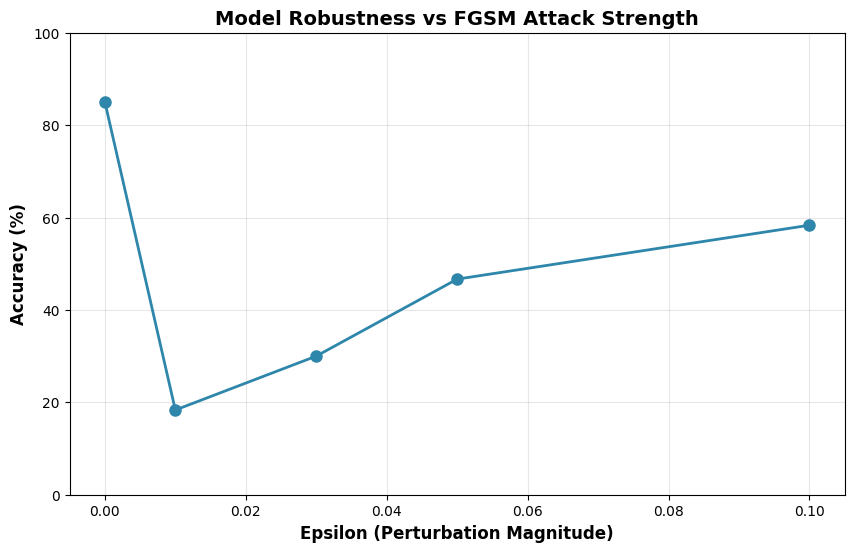


✅ FGSM ATTACK EVALUATION COMPLETE


In [9]:
import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tqdm import tqdm
from tensorflow.keras.models import load_model

# ============================================================================
# FGSM ATTACK IMPLEMENTATION
# ============================================================================

def fgsm_attack(model, images, labels, epsilon=0.03):
    """
    Generates adversarial examples using the Fast Gradient Sign Method (FGSM).
    
    Args:
        model: Trained Keras model
        images: Input images to perturb
        labels: True labels for the images
        epsilon: Magnitude of perturbation
        
    Returns:
        Adversarial images as numpy array
    """
    images = tf.cast(images, tf.float32)
    labels = tf.cast(labels, tf.float32)
    
    with tf.GradientTape() as tape:
        tape.watch(images)
        predictions = model(images, training=False)
        loss = tf.keras.losses.categorical_crossentropy(labels, predictions)
        gradient = tape.gradient(loss, images)
    
    signed_grad = tf.sign(gradient)
    adversarial_images = images + epsilon * signed_grad
    adversarial_images = tf.clip_by_value(adversarial_images, 0.0, 1.0)
    
    return adversarial_images.numpy()


def evaluate_fgsm_robustness(model, X_test, y_test, epsilons=[0.01, 0.03, 0.05, 0.1]):
    """
    Evaluate model robustness against FGSM attacks with different epsilon values.
    
    Args:
        model: Trained Keras model
        X_test: Test images
        y_test: Test labels
        epsilons: List of epsilon values to test
        
    Returns:
        results: Dictionary containing attack results for each epsilon
        clean_acc: Baseline accuracy on clean images
    """
    results = {}
    batch_size = 8
    
    # Evaluate on clean data
    print("=" * 70)
    print("CLEAN TEST (NO ATTACK)")
    print("=" * 70)
    clean_loss, clean_acc = model.evaluate(X_test, y_test, verbose=0)
    print(f"Clean Accuracy: {clean_acc * 100:.2f}%")
    print(f"Clean Loss: {clean_loss:.4f}\n")
    
    # Test each epsilon value
    for eps in epsilons:
        print("=" * 70)
        print(f"FGSM ATTACK - Epsilon = {eps}")
        print("=" * 70)
        
        X_adv = []
        
        # Generate adversarial examples in batches
        for i in tqdm(range(0, len(X_test), batch_size), 
                     desc=f"Generating adversarial examples (ε={eps})"):
            batch_images = X_test[i:i + batch_size]
            batch_labels = y_test[i:i + batch_size]
            
            adv_batch = fgsm_attack(model, batch_images, batch_labels, epsilon=eps)
            X_adv.append(adv_batch)
        
        X_adv = np.concatenate(X_adv, axis=0)
        
        # Evaluate on adversarial examples
        loss, accuracy = model.evaluate(X_adv, y_test, verbose=0)
        
        results[eps] = {
            'accuracy': accuracy,
            'loss': loss,
            'adversarial_examples': X_adv,
            'accuracy_drop': clean_acc - accuracy
        }
        
        print(f"Adversarial Accuracy: {accuracy * 100:.2f}%")
        print(f"Adversarial Loss: {loss:.4f}")
        print(f"Accuracy Drop: {(clean_acc - accuracy) * 100:.2f}%\n")
    
    return results, clean_acc


def visualize_robustness(fgsm_results, clean_accuracy, save_path):
    """
    Create and save a plot showing model robustness vs attack strength.
    
    Args:
        fgsm_results: Dictionary of FGSM attack results
        clean_accuracy: Baseline accuracy on clean images
        save_path: Path to save the plot
    """
    epsilons = list(fgsm_results.keys())
    accuracies = [fgsm_results[eps]['accuracy'] * 100 for eps in epsilons]
    
    plt.figure(figsize=(10, 6))
    plt.plot([0] + list(epsilons), 
             [clean_accuracy * 100] + accuracies, 
             marker='o', 
             linewidth=2, 
             markersize=8,
             color='#2E86AB')
    
    plt.xlabel('Epsilon (Perturbation Magnitude)', fontsize=12, fontweight='bold')
    plt.ylabel('Accuracy (%)', fontsize=12, fontweight='bold')
    plt.title('Model Robustness vs FGSM Attack Strength', fontsize=14, fontweight='bold')
    plt.grid(True, alpha=0.3)
    plt.ylim([0, 100])
    
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"✓ Plot saved to {save_path}")
    plt.show()


# ============================================================================
# MAIN EXECUTION
# ============================================================================

if __name__ == "__main__":
    WORK_DIR = "./working"
    
    # Load model
    print("\n" + "=" * 70)
    print("LOADING MODEL")
    print("=" * 70)
    model = load_model(os.path.join(WORK_DIR, "deepfake_detection_best.keras"))
    print("✓ Model loaded successfully\n")
    
    # Run FGSM evaluation
    print("=" * 70)
    print("EVALUATING MODEL ROBUSTNESS")
    print("=" * 70 + "\n")
    X_test = np.load(os.path.join(WORK_DIR, "X_test.npy"))
    y_test = np.load(os.path.join(WORK_DIR, "y_test.npy"))
    fgsm_results, clean_accuracy = evaluate_fgsm_robustness(model, X_test, y_test)
    
    # Save adversarial examples
    print("\n" + "=" * 70)
    print("SAVING ADVERSARIAL EXAMPLES")
    print("=" * 70)
    X_adv_fgsm = fgsm_results[0.03]['adversarial_examples']
    save_path = os.path.join(WORK_DIR, 'X_test_fgsm_adversarial.npy')
    np.save(save_path, X_adv_fgsm)
    
    print(f"✓ FGSM (ε=0.03) adversarial examples saved")
    print(f"  Path: {save_path}")
    print(f"  Shape: {X_adv_fgsm.shape}")
    print(f"  Size: {X_adv_fgsm.nbytes / (1024**3):.2f} GB\n")
    
    # Visualize results
    print("=" * 70)
    print("GENERATING VISUALIZATION")
    print("=" * 70)
    plot_path = os.path.join(WORK_DIR, 'fgsm_robustness.png')
    visualize_robustness(fgsm_results, clean_accuracy, plot_path)
    
    print("\n" + "=" * 70)
    print("✅ FGSM ATTACK EVALUATION COMPLETE")
    print("=" * 70)

In [10]:
import os
import numpy as np
import tensorflow as tf
from tqdm import tqdm
from tensorflow.keras.models import load_model

# ============================================================================
# PGD ATTACK IMPLEMENTATION
# ============================================================================

def pgd_attack(model, images, labels, epsilon=0.03, alpha=0.01, num_iter=10):
    """
    Generates adversarial examples using the Projected Gradient Descent (PGD) attack.
    
    PGD is an iterative variant of FGSM that applies multiple small perturbations
    while projecting back to the epsilon ball after each step.
    
    Args:
        model: Trained Keras model to attack
        images: Input images to perturb
        labels: True labels for the images
        epsilon: Maximum perturbation magnitude (L-infinity norm)
        alpha: Step size for each iteration
        num_iter: Number of iterations to perform
        
    Returns:
        Adversarial images as numpy array
    """
    images = tf.Variable(images, dtype=tf.float32)
    labels = tf.cast(labels, tf.float32)
    
    original_images = images.numpy()
    
    # Iteratively perturb the images
    for i in range(num_iter):
        with tf.GradientTape() as tape:
            tape.watch(images)
            predictions = model(images, training=False)
            loss = tf.keras.losses.categorical_crossentropy(labels, predictions)
        
        gradient = tape.gradient(loss, images)
        signed_grad = tf.sign(gradient)
        
        # Take a step in the direction of the gradient
        images.assign_add(alpha * signed_grad)
        
        # Project back to epsilon ball
        perturbation = images - original_images
        perturbation = tf.clip_by_value(perturbation, -epsilon, epsilon)
        images.assign(original_images + perturbation)
        
        # Ensure pixel values remain valid [0, 1]
        images.assign(tf.clip_by_value(images, 0.0, 1.0))
    
    return images.numpy()


def evaluate_pgd_robustness(model, X_test, y_test, epsilon=0.03, alpha=0.01, num_iter=10):
    """
    Evaluate model robustness against PGD attacks.
    
    Args:
        model: Trained Keras model
        X_test: Test images
        y_test: Test labels
        epsilon: Maximum perturbation magnitude
        alpha: Step size for each iteration
        num_iter: Number of PGD iterations
        
    Returns:
        X_adv: Adversarial examples
        accuracy: Model accuracy on adversarial examples
        loss: Model loss on adversarial examples
    """
    batch_size = 8
    
    print("=" * 70)
    print(f"PGD ATTACK - ε={epsilon}, α={alpha}, iterations={num_iter}")
    print("=" * 70)
    
    # Evaluate on clean data
    print("\n--- Clean Test (No Attack) ---")
    clean_loss, clean_acc = model.evaluate(X_test, y_test, verbose=0)
    print(f"Clean Accuracy: {clean_acc * 100:.2f}%")
    print(f"Clean Loss: {clean_loss:.4f}\n")
    
    # Generate adversarial examples in batches
    X_adv = []
    
    for i in tqdm(range(0, len(X_test), batch_size), 
                 desc="Generating PGD adversarial examples"):
        batch_images = X_test[i:i + batch_size]
        batch_labels = y_test[i:i + batch_size]
        
        adv_batch = pgd_attack(
            model, batch_images, batch_labels,
            epsilon=epsilon, alpha=alpha, num_iter=num_iter
        )
        X_adv.append(adv_batch)
    
    X_adv = np.concatenate(X_adv, axis=0)
    
    # Evaluate on adversarial examples
    print("\n--- Adversarial Test Results ---")
    loss, accuracy = model.evaluate(X_adv, y_test, verbose=0)
    
    print(f"Adversarial Accuracy: {accuracy * 100:.2f}%")
    print(f"Adversarial Loss: {loss:.4f}")
    print(f"Accuracy Drop: {(clean_acc - accuracy) * 100:.2f}%")
    
    return X_adv, accuracy, loss


def save_adversarial_examples(X_adv, save_dir, filename='X_test_pgd_adversarial.npy'):
    """
    Save adversarial examples to disk.
    
    Args:
        X_adv: Adversarial examples to save
        save_dir: Directory to save to
        filename: Name of the output file
    """
    print("\n" + "=" * 70)
    print("SAVING ADVERSARIAL EXAMPLES")
    print("=" * 70)
    
    save_path = os.path.join(save_dir, filename)
    np.save(save_path, X_adv)
    
    print(f"✓ PGD adversarial examples saved")
    print(f"  Path: {save_path}")
    print(f"  Shape: {X_adv.shape}")
    print(f"  Size: {X_adv.nbytes / (1024**3):.2f} GB")


# ============================================================================
# MAIN EXECUTION
# ============================================================================

if __name__ == "__main__":
    WORK_DIR = "./working"
    
    # Load model
    print("\n" + "=" * 70)
    print("LOADING MODEL")
    print("=" * 70)
    model = load_model(os.path.join(WORK_DIR, "deepfake_detection_best.keras"))
    print("✓ Model loaded successfully\n")
    
    # Run PGD evaluation
    print("=" * 70)
    print("EVALUATING MODEL ROBUSTNESS AGAINST PGD")
    print("=" * 70 + "\n")
    
    X_adv_pgd, pgd_acc, pgd_loss = evaluate_pgd_robustness(
        model, X_test, y_test,
        epsilon=0.03,
        alpha=0.01,
        num_iter=10
    )
    
    # Save adversarial examples
    save_adversarial_examples(X_adv_pgd, WORK_DIR)
    
    print("\n" + "=" * 70)
    print("✅ PGD ATTACK EVALUATION COMPLETE")
    print("=" * 70)


LOADING MODEL
✓ Model loaded successfully

EVALUATING MODEL ROBUSTNESS AGAINST PGD

PGD ATTACK - ε=0.03, α=0.01, iterations=10

--- Clean Test (No Attack) ---
Clean Accuracy: 85.00%
Clean Loss: 4.3502



Generating PGD adversarial examples: 100%|██████████| 8/8 [05:29<00:00, 41.17s/it]



--- Adversarial Test Results ---
Adversarial Accuracy: 0.00%
Adversarial Loss: 14.0180
Accuracy Drop: 85.00%

SAVING ADVERSARIAL EXAMPLES
✓ PGD adversarial examples saved
  Path: ./working/X_test_pgd_adversarial.npy
  Shape: (60, 10, 128, 128, 3)
  Size: 0.11 GB

✅ PGD ATTACK EVALUATION COMPLETE



LOADING MODEL
✓ Model loaded successfully

RUNNING 2D-MALAFIDE ATTACK

2D-MALAFIDE ATTACK

🔍 Data Sanity Check:
X_test dtype: float64
X_test shape: (60, 10, 128, 128, 3)
X_test range: [0.0000, 1.0000]
y_test shape: (60, 2)
⚠️  Converting X_test from float64 to float32...
✓ Converted to float32

📊 Dataset Statistics:
Total test samples: 60
Real samples (class 0): 35
Fake samples (class 1): 25

🎯 Using 25 fake images for filter training
✓ Initialized 3x3 filter
  Filter shape: (3, 3, 3)
  Filter dtype: <dtype: 'float32'>
  Initial center values: [1. 1. 1.]

Training 2D-Malafide Filter
Filter size: 3x3
Training samples: 25
Learning rate: 0.01
Iterations: 100
Target class: 0 (Real)

Initial avg 'Real' score: 0.2715
Initial avg 'Fake' score: 0.7285



Training filter:  20%|██        | 20/100 [07:00<26:55, 20.20s/it]

Iteration 20/100 - Avg Real Score: 0.8882 - Loss: 0.8882


Training filter:  40%|████      | 40/100 [13:30<19:31, 19.52s/it]

Iteration 40/100 - Avg Real Score: 0.8844 - Loss: 0.8844


...

Training filter:  80%|████████  | 80/100 [27:30<07:06, 21.33s/it]

Iteration 80/100 - Avg Real Score: 0.9030 - Loss: 0.9030


Training filter: 100%|██████████| 100/100 [34:25<00:00, 20.66s/it]

Iteration 100/100 - Avg Real Score: 0.9099 - Loss: 0.9099



Filter Training Complete!
Initial avg 'Real' score: 0.2715
Final avg 'Real' score:   0.9101
Improvement: 0.6386


🔄 Generating adversarial examples for entire test set...

2D-Malafide Attack Evaluation

1️⃣ Clean Test Set Performance:
Clean Accuracy: 85.00%
Clean Loss: 4.3502

2️⃣ Adversarial Test Set Performance:
Adversarial Accuracy: 58.33%
Adversarial Loss: 5.1453
Accuracy Drop: 26.67%
Attack Success Rate: 31.37%

3️⃣ Class-wise Analysis:
Real Images (Class 0):
  Clean Accuracy: 94.29%
  Adversarial Accuracy: 100.00%
  Attack Impact: -5.71%

Fake Images (Class 1):
  Clean Accuracy: 72.00%
  Adversarial Accuracy: 0.00%
  Attack Impact: 72.00%

4️⃣ Prediction Distribution:
Clean predictions - Real: 40, Fake: 20
Adversarial predictions - Real: 60, Fake: 0

⚠️  WARNING: ALL adversarial samples predicted as class 0!


📊 Generating visualizations...


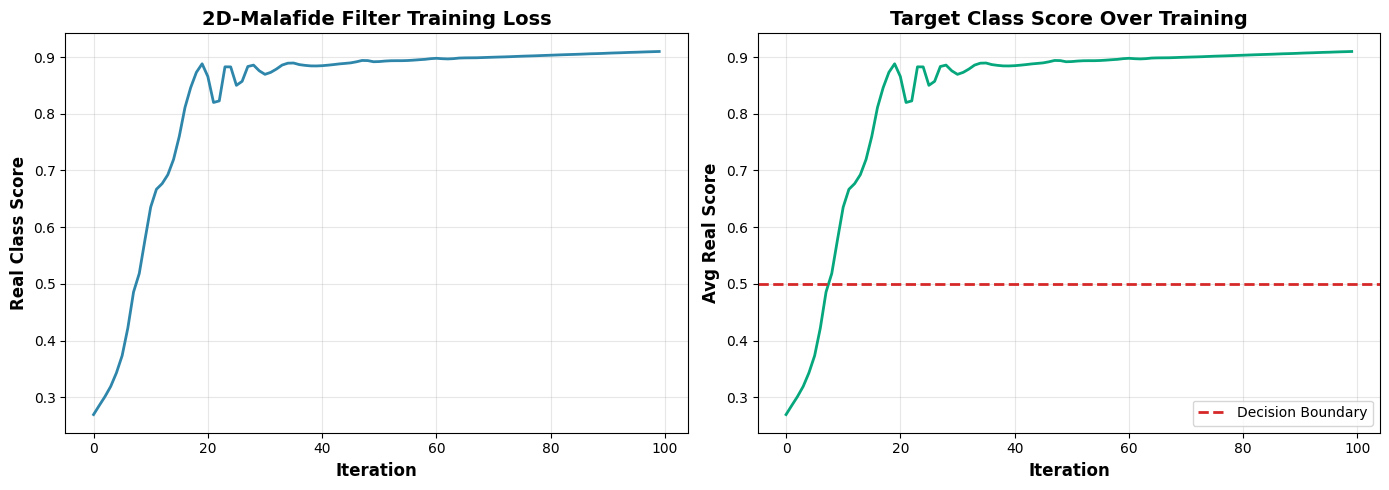

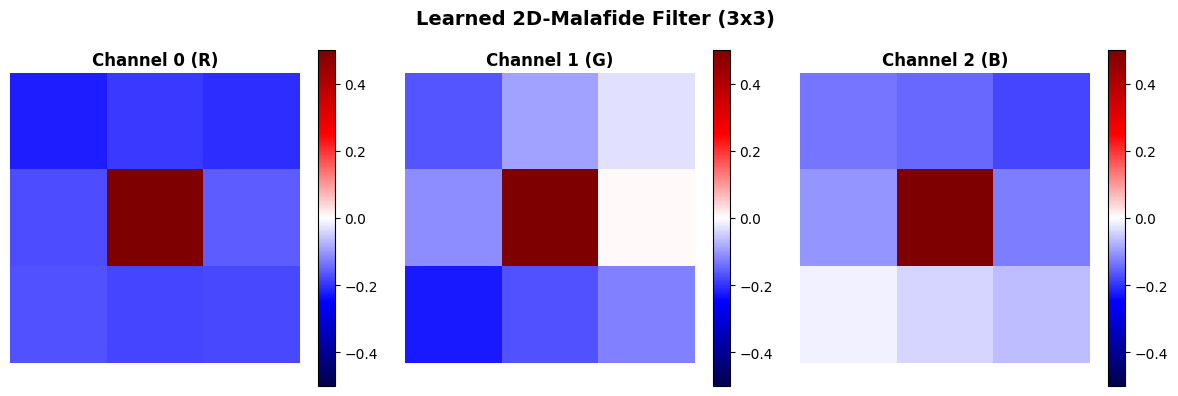


SAVING RESULTS
✓ Training history plot saved to ./working/2d_malafide_training.png


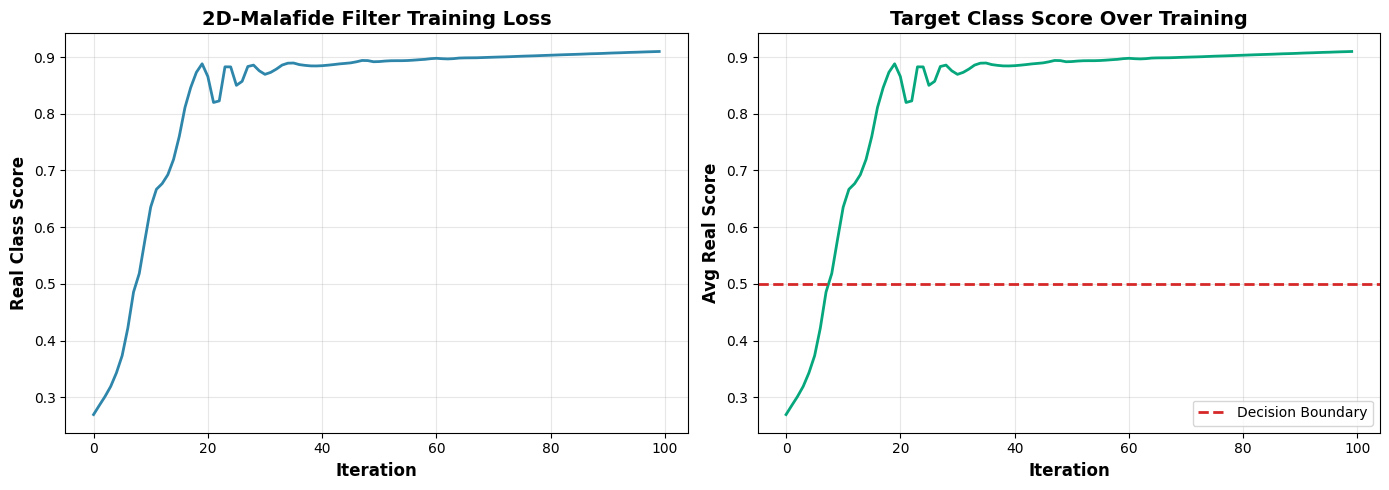

✓ Filter visualization saved to ./working/2d_malafide_filter.png


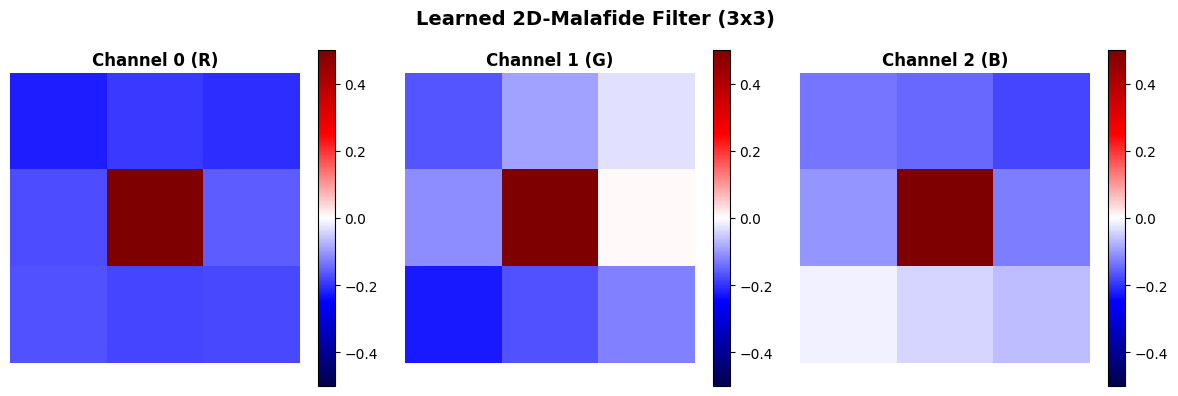

✓ Adversarial examples saved to ./working/X_test_malafide_adversarial.npy
✓ Learned filter saved to ./working/malafide_filter.npy
✓ Visualizations saved to ./working/

✅ 2D-MALAFIDE ATTACK COMPLETE


In [11]:
import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tqdm import tqdm
from tensorflow.keras.models import load_model

# ============================================================================
# 2D-MALAFIDE ATTACK IMPLEMENTATION
# ============================================================================

class Malafide2DAttack:
    """
    2D-Malafide: Adversarial attack using optimized 2D convolutional filters.
    
    This attack learns a small convolutional filter that, when applied to images,
    causes a deepfake detection model to misclassify them. Unlike pixel-level
    attacks, this learns a transferable filter that can fool the model.
    
    Based on: "2D-Malafide: Adversarial Attacks Against Face Deepfake Detection Systems"
    Galdi et al., 2024
    """
    
    def __init__(self, filter_size=3, learning_rate=0.01, num_iterations=100):
        """
        Initialize the 2D-Malafide attack.
        
        Args:
            filter_size: Size of 2D convolutional filter (e.g., 3 for 3x3, 5 for 5x5)
            learning_rate: Learning rate for filter optimization
            num_iterations: Number of optimization iterations
        """
        self.filter_size = filter_size
        self.learning_rate = learning_rate
        self.num_iterations = num_iterations
        self.filter = None
        self.training_history = {'loss': [], 'avg_score': []}
    
    def initialize_filter(self, num_channels=3):
        """
        Initialize 2D convolutional filter with small random values.
        
        The filter is initialized near the identity transformation to start
        with minimal perturbation, then optimized to fool the model.
        """
        # Initialize with small random values
        filter_init = np.random.randn(
            self.filter_size, self.filter_size, num_channels
        ).astype(np.float32) * 0.01
        
        # Set center to 1 for near-identity initialization
        center = self.filter_size // 2
        filter_init[center, center, :] = 1.0
        
        # Create trainable TensorFlow variable
        self.filter = tf.Variable(filter_init, dtype=tf.float32, trainable=True)
        
        print(f"✓ Initialized {self.filter_size}x{self.filter_size} filter")
        print(f"  Filter shape: {self.filter.shape}")
        print(f"  Filter dtype: {self.filter.dtype}")
        print(f"  Initial center values: {filter_init[center, center, :]}")
    
    def apply_filter(self, images):
        """
        Apply learned 2D filter to images via convolution.
        
        Args:
            images: Input images (batch_size, frame_count, height, width, channels)
            
        Returns:
            filtered_images: Images after applying the adversarial filter
        """
        images = tf.cast(images, tf.float32)
        batch_size, frame_count, height, width, channels = images.shape
        
        # Reshape to (batch_size * frame_count, height, width, channels)
        images_flat = tf.reshape(images, [-1, height, width, channels])
        
        # Apply filter to each channel separately
        filtered_channels = []
        for c in range(channels):
            # Extract channel
            channel_images = images_flat[:, :, :, c:c+1]
            channel_images = tf.cast(channel_images, tf.float32)
            
            # Create kernel for this channel
            kernel = self.filter[:, :, c:c+1, tf.newaxis]
            kernel = tf.cast(kernel, tf.float32)
            
            # Apply 2D convolution
            filtered_channel = tf.nn.conv2d(
                channel_images,
                kernel,
                strides=[1, 1, 1, 1],
                padding='SAME'
            )
            filtered_channels.append(filtered_channel)
        
        # Concatenate channels and clip to valid range
        filtered_flat = tf.concat(filtered_channels, axis=-1)
        filtered_flat = tf.clip_by_value(filtered_flat, 0.0, 1.0)
        
        # Reshape back to original shape
        filtered_images = tf.reshape(
            filtered_flat, 
            [batch_size, frame_count, height, width, channels]
        )
        
        return filtered_images
    
    def train_filter(self, model, fake_images, target_class=0):
        """
        Train the adversarial filter to make fake images appear real.
        
        Args:
            model: Target deepfake detection model
            fake_images: Fake images to attack (label=1, should be misclassified as real=0)
            target_class: Target class (0 for real, 1 for fake)
            
        Returns:
            Learned filter as numpy array
        """
        fake_images = tf.cast(fake_images, tf.float32).numpy()
        
        if self.filter is None:
            self.initialize_filter(num_channels=int(fake_images.shape[-1]))
        
        optimizer = tf.keras.optimizers.Adam(learning_rate=self.learning_rate)
        
        # Print training configuration
        print(f"\n{'=' * 60}")
        print("Training 2D-Malafide Filter")
        print(f"{'=' * 60}")
        print(f"Filter size: {self.filter_size}x{self.filter_size}")
        print(f"Training samples: {len(fake_images)}")
        print(f"Learning rate: {self.learning_rate}")
        print(f"Iterations: {self.num_iterations}")
        print(f"Target class: {target_class} ({'Real' if target_class == 0 else 'Fake'})")
        print(f"{'=' * 60}\n")
        
        # Check initial predictions
        initial_preds = model.predict(fake_images, verbose=0)
        initial_real_scores = initial_preds[:, target_class]
        print(f"Initial avg 'Real' score: {np.mean(initial_real_scores):.4f}")
        print(f"Initial avg 'Fake' score: {np.mean(initial_preds[:, 1]):.4f}\n")
        
        # Training loop
        for iteration in tqdm(range(self.num_iterations), desc="Training filter"):
            with tf.GradientTape() as tape:
                # Apply current filter
                fake_images_tf = tf.cast(fake_images, tf.float32)
                filtered_images = self.apply_filter(fake_images_tf)
                
                # Get model predictions
                predictions = model(filtered_images, training=False)
                
                # Loss: maximize score for target class (minimize negative)
                target_scores = predictions[:, target_class]
                loss = -tf.reduce_mean(target_scores)
            
            # Compute and apply gradients
            gradients = tape.gradient(loss, [self.filter])
            
            if gradients[0] is None:
                print(f"⚠️  Warning: Gradient is None at iteration {iteration}")
                continue
            
            optimizer.apply_gradients(zip(gradients, [self.filter]))
            
            # Record history
            avg_score = tf.reduce_mean(target_scores).numpy()
            self.training_history['loss'].append(-loss.numpy())
            self.training_history['avg_score'].append(avg_score)
            
            # Periodic logging
            if (iteration + 1) % 20 == 0:
                print(f"Iteration {iteration+1}/{self.num_iterations} - "
                      f"Avg Real Score: {avg_score:.4f} - Loss: {-loss.numpy():.4f}")
        
        # Check final predictions
        final_filtered = self.apply_filter(tf.cast(fake_images, tf.float32))
        final_preds = model.predict(final_filtered, verbose=0)
        final_real_scores = final_preds[:, target_class]
        
        print(f"\n{'=' * 60}")
        print("Filter Training Complete!")
        print(f"{'=' * 60}")
        print(f"Initial avg 'Real' score: {np.mean(initial_real_scores):.4f}")
        print(f"Final avg 'Real' score:   {np.mean(final_real_scores):.4f}")
        print(f"Improvement: {np.mean(final_real_scores) - np.mean(initial_real_scores):.4f}")
        print(f"{'=' * 60}\n")
        
        return self.filter.numpy()
    
    def attack(self, images):
        """
        Apply trained filter to generate adversarial examples.
        
        Args:
            images: Input images to attack
            
        Returns:
            Adversarial images
        """
        if self.filter is None:
            raise ValueError("Filter not trained. Call train_filter() first.")
        
        images = tf.cast(images, tf.float32)
        return self.apply_filter(images).numpy()
    
    def plot_training_history(self, save_path=None):
        """Plot training loss and score history."""
        if not self.training_history['loss']:
            print("No training history to plot!")
            return
        
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
        
        # Plot loss
        ax1.plot(self.training_history['loss'], linewidth=2, color='#2E86AB')
        ax1.set_xlabel('Iteration', fontsize=12, fontweight='bold')
        ax1.set_ylabel('Real Class Score', fontsize=12, fontweight='bold')
        ax1.set_title('2D-Malafide Filter Training Loss', fontsize=14, fontweight='bold')
        ax1.grid(True, alpha=0.3)
        
        # Plot average score
        ax2.plot(self.training_history['avg_score'], linewidth=2, color='#06A77D')
        ax2.set_xlabel('Iteration', fontsize=12, fontweight='bold')
        ax2.set_ylabel('Avg Real Score', fontsize=12, fontweight='bold')
        ax2.set_title('Target Class Score Over Training', fontsize=14, fontweight='bold')
        ax2.grid(True, alpha=0.3)
        ax2.axhline(y=0.5, color='#D62828', linestyle='--', linewidth=2, label='Decision Boundary')
        ax2.legend()
        
        plt.tight_layout()
        if save_path:
            plt.savefig(save_path, dpi=300, bbox_inches='tight')
            print(f"✓ Training history plot saved to {save_path}")
        plt.show()
    
    def visualize_filter(self, save_path=None):
        """Visualize the learned adversarial filter."""
        if self.filter is None:
            print("No filter to visualize!")
            return
        
        filter_np = self.filter.numpy()
        fig, axes = plt.subplots(1, 3, figsize=(12, 4))
        
        for c in range(min(3, filter_np.shape[2])):
            im = axes[c].imshow(
                filter_np[:, :, c], 
                cmap='seismic', 
                vmin=-0.5, 
                vmax=0.5
            )
            axes[c].set_title(
                f'Channel {c} ({"RGB"[c]})', 
                fontsize=12, 
                fontweight='bold'
            )
            axes[c].axis('off')
            plt.colorbar(im, ax=axes[c])
        
        plt.suptitle(
            f'Learned 2D-Malafide Filter ({self.filter_size}x{self.filter_size})',
            fontsize=14, 
            fontweight='bold'
        )
        plt.tight_layout()
        if save_path:
            plt.savefig(save_path, dpi=300, bbox_inches='tight')
            print(f"✓ Filter visualization saved to {save_path}")
        plt.show()


# ============================================================================
# EVALUATION FUNCTIONS
# ============================================================================

def evaluate_2d_malafide_robustness(model, X_test, y_test, X_adv, attack_name="2D-Malafide"):
    """
    Comprehensive evaluation of 2D-Malafide attack effectiveness.
    
    Args:
        model: Deepfake detection model
        X_test: Clean test images
        y_test: Test labels
        X_adv: Adversarial images
        attack_name: Name of attack for display
        
    Returns:
        Dictionary containing evaluation metrics
    """
    print(f"\n{'=' * 70}")
    print(f"{attack_name} Attack Evaluation")
    print(f"{'=' * 70}")
    
    # Clean evaluation
    print("\n1️⃣ Clean Test Set Performance:")
    clean_loss, clean_acc = model.evaluate(X_test, y_test, verbose=0)
    y_pred_clean = model.predict(X_test, verbose=0)
    print(f"Clean Accuracy: {clean_acc * 100:.2f}%")
    print(f"Clean Loss: {clean_loss:.4f}")
    
    # Adversarial evaluation
    print(f"\n2️⃣ Adversarial Test Set Performance:")
    adv_loss, adv_acc = model.evaluate(X_adv, y_test, verbose=0)
    y_pred_adv = model.predict(X_adv, verbose=0)
    print(f"Adversarial Accuracy: {adv_acc * 100:.2f}%")
    print(f"Adversarial Loss: {adv_loss:.4f}")
    print(f"Accuracy Drop: {(clean_acc - adv_acc) * 100:.2f}%")
    print(f"Attack Success Rate: {(1 - adv_acc / clean_acc) * 100:.2f}%")
    
    # Class-wise analysis
    print(f"\n3️⃣ Class-wise Analysis:")
    y_true = np.argmax(y_test, axis=1)
    y_pred_clean_labels = np.argmax(y_pred_clean, axis=1)
    y_pred_adv_labels = np.argmax(y_pred_adv, axis=1)
    
    # Real class (0)
    real_indices = np.where(y_true == 0)[0]
    if len(real_indices) > 0:
        real_clean_acc = np.mean(y_pred_clean_labels[real_indices] == 0)
        real_adv_acc = np.mean(y_pred_adv_labels[real_indices] == 0)
        print(f"Real Images (Class 0):")
        print(f"  Clean Accuracy: {real_clean_acc * 100:.2f}%")
        print(f"  Adversarial Accuracy: {real_adv_acc * 100:.2f}%")
        print(f"  Attack Impact: {(real_clean_acc - real_adv_acc) * 100:.2f}%")
    
    # Fake class (1)
    fake_indices = np.where(y_true == 1)[0]
    if len(fake_indices) > 0:
        fake_clean_acc = np.mean(y_pred_clean_labels[fake_indices] == 1)
        fake_adv_acc = np.mean(y_pred_adv_labels[fake_indices] == 1)
        print(f"\nFake Images (Class 1):")
        print(f"  Clean Accuracy: {fake_clean_acc * 100:.2f}%")
        print(f"  Adversarial Accuracy: {fake_adv_acc * 100:.2f}%")
        print(f"  Attack Impact: {(fake_clean_acc - fake_adv_acc) * 100:.2f}%")
    
    # Prediction distribution
    print(f"\n4️⃣ Prediction Distribution:")
    print(f"Clean predictions - Real: {np.sum(y_pred_clean_labels == 0)}, "
          f"Fake: {np.sum(y_pred_clean_labels == 1)}")
    print(f"Adversarial predictions - Real: {np.sum(y_pred_adv_labels == 0)}, "
          f"Fake: {np.sum(y_pred_adv_labels == 1)}")
    
    # Check if all adversarial samples are same class
    if len(np.unique(y_pred_adv_labels)) == 1:
        print(f"\n⚠️  WARNING: ALL adversarial samples predicted as class {y_pred_adv_labels[0]}!")
    
    print(f"\n{'=' * 70}")
    
    return {
        'clean_acc': clean_acc,
        'adv_acc': adv_acc,
        'accuracy_drop': clean_acc - adv_acc,
        'attack_success_rate': (1 - adv_acc / clean_acc) if clean_acc > 0 else 0
    }


def apply_2d_malafide_attack(model, X_test, y_test, filter_size=3, num_iterations=100,
                              train_samples=100, learning_rate=0.01):
    """
    Apply 2D-Malafide attack to test set with comprehensive debugging.
    
    Args:
        model: Deepfake detection model
        X_test: Test images
        y_test: Test labels
        filter_size: Size of convolutional filter
        num_iterations: Number of training iterations
        train_samples: Number of samples to use for filter training
        learning_rate: Learning rate for filter optimization
        
    Returns:
        X_adv: Adversarial images
        learned_filter: Learned filter weights
        malafide_obj: Malafide attack object
        results: Evaluation results dictionary
    """
    print(f"\n{'=' * 70}")
    print("2D-MALAFIDE ATTACK")
    print(f"{'=' * 70}\n")
    
    # Data sanity check
    print("🔍 Data Sanity Check:")
    print(f"X_test dtype: {X_test.dtype}")
    print(f"X_test shape: {X_test.shape}")
    print(f"X_test range: [{X_test.min():.4f}, {X_test.max():.4f}]")
    print(f"y_test shape: {y_test.shape}")
    
    # Convert to float32 if necessary
    if X_test.dtype != np.float32:
        print(f"⚠️  Converting X_test from {X_test.dtype} to float32...")
        X_test = X_test.astype(np.float32)
        print(f"✓ Converted to {X_test.dtype}")
    
    # Separate fake images (label=1) for filter training
    fake_indices = np.where(np.argmax(y_test, axis=1) == 1)[0]
    fake_images = X_test[fake_indices]
    
    print(f"\n📊 Dataset Statistics:")
    print(f"Total test samples: {len(X_test)}")
    print(f"Real samples (class 0): {len(X_test) - len(fake_images)}")
    print(f"Fake samples (class 1): {len(fake_images)}")
    
    if len(fake_images) == 0:
        print("\n❌ ERROR: No fake images found in test set!")
        return None, None, None, None
    
    # Initialize and train 2D-Malafide filter
    malafide = Malafide2DAttack(
        filter_size=filter_size,
        learning_rate=learning_rate,
        num_iterations=num_iterations
    )
    
    # Train filter on subset of fake images
    train_subset = fake_images[:min(train_samples, len(fake_images))]
    print(f"\n🎯 Using {len(train_subset)} fake images for filter training")
    
    learned_filter = malafide.train_filter(model, train_subset, target_class=0)
    
    # Apply filter to all test images
    print("\n🔄 Generating adversarial examples for entire test set...")
    X_adv = malafide.attack(X_test)
    
    # Evaluate
    results = evaluate_2d_malafide_robustness(model, X_test, y_test, X_adv)
    
    # Visualize
    print("\n📊 Generating visualizations...")
    malafide.plot_training_history()
    malafide.visualize_filter()
    
    return X_adv, learned_filter, malafide, results


# ============================================================================
# MAIN EXECUTION
# ============================================================================

if __name__ == "__main__":
    WORK_DIR = "./working"
    
    # Load model
    print("\n" + "=" * 70)
    print("LOADING MODEL")
    print("=" * 70)
    model_path = os.path.join(WORK_DIR, "deepfake_detection_final.keras")
    model = load_model(model_path)
    print("✓ Model loaded successfully\n")
    
    # Run attack
    print("=" * 70)
    print("RUNNING 2D-MALAFIDE ATTACK")
    print("=" * 70)
    
    X_adv_malafide, learned_filter, malafide_obj, results = apply_2d_malafide_attack(
        model, X_test, y_test,
        filter_size=3,          # Try 3, 5, or 7
        num_iterations=100,     # Increase for better results
        train_samples=100,      # Number of fake samples for training
        learning_rate=0.01      # Learning rate
    )
    
    # Save results
    if X_adv_malafide is not None:
        print("\n" + "=" * 70)
        print("SAVING RESULTS")
        print("=" * 70)
        
        np.save(os.path.join(WORK_DIR, "X_test_malafide_adversarial.npy"), X_adv_malafide)
        np.save(os.path.join(WORK_DIR, "malafide_filter.npy"), learned_filter)
        
        # Save visualizations if they weren't saved during generation
        malafide_obj.plot_training_history(
            save_path=os.path.join(WORK_DIR, '2d_malafide_training.png')
        )
        malafide_obj.visualize_filter(
            save_path=os.path.join(WORK_DIR, '2d_malafide_filter.png')
        )
        
        print(f"✓ Adversarial examples saved to {WORK_DIR}/X_test_malafide_adversarial.npy")
        print(f"✓ Learned filter saved to {WORK_DIR}/malafide_filter.npy")
        print(f"✓ Visualizations saved to {WORK_DIR}/")
        
        print("\n" + "=" * 70)
        print("✅ 2D-MALAFIDE ATTACK COMPLETE")
        print("=" * 70)
    else:
        print("\n" + "=" * 70)
        print("❌ ATTACK FAILED")
        print("=" * 70)

LOADING DATA FROM NPY FILES

✓ Data loaded successfully!
  X_train: (558, 10, 128, 128, 3)
  y_train: (558, 2)
  X_test: (60, 10, 128, 128, 3)
  y_test: (60, 2)
  X_val: (60, 10, 128, 128, 3)
  y_val: (60, 2)

VERIFYING AND FIXING DATA TYPES

1️⃣ X_train:
   Type: <class 'numpy.ndarray'>
   Dtype: float64
   Shape: (558, 10, 128, 128, 3)
   ✓ Fixed to float32

2️⃣ y_train:
   Type: <class 'numpy.ndarray'>
   Dtype: float64
   Shape: (558, 2)
   ✓ Fixed to float32

3️⃣ X_val:
   Type: <class 'numpy.ndarray'>
   Dtype: float64
   Shape: (60, 10, 128, 128, 3)
   ✓ Fixed to float32

4️⃣ y_val:
   Type: <class 'numpy.ndarray'>
   Dtype: float64
   Shape: (60, 2)
   ✓ Fixed to float32

5️⃣ X_test:
   Type: <class 'numpy.ndarray'>
   Dtype: float64
   Shape: (60, 10, 128, 128, 3)
   ✓ Fixed to float32

6️⃣ y_test:
   Type: <class 'numpy.ndarray'>
   Dtype: float64
   Shape: (60, 2)
   ✓ Fixed to float32

✓ ALL DATA VERIFIED AND FIXED

LOADING PRE-TRAINED 2D-MALAFIDE FILTER

⚠️  WARNING: Pre-t

Training (adv_ratio=50.0%): 100%|██████████| 70/70 [01:36<00:00,  1.38s/it, loss=4.7184, acc=0.6760]



📊 Epoch Results:
  Training Loss:         4.7184
  Training Accuracy:     67.60%
  Validation Loss:       4.1039
  Validation Accuracy:   90.00%
  Clean Samples:         279
  Adversarial Samples:   279

✅ New best validation accuracy: 90.00%

Epoch 2/20


Training (adv_ratio=50.0%): 100%|██████████| 70/70 [01:06<00:00,  1.05it/s, loss=4.4856, acc=0.7074]



📊 Epoch Results:
  Training Loss:         4.4856
  Training Accuracy:     70.74%
  Validation Loss:       3.9366
  Validation Accuracy:   88.33%
  Clean Samples:         279
  Adversarial Samples:   279

Epoch 3/20


...


📊 Epoch Results:
  Training Loss:         2.9763
  Training Accuracy:     73.31%
  Validation Loss:       2.5903
  Validation Accuracy:   88.33%
  Clean Samples:         279
  Adversarial Samples:   279

Epoch 19/20


Training (adv_ratio=50.0%): 100%|██████████| 70/70 [01:34<00:00,  1.35s/it, loss=2.9531, acc=0.6815]



📊 Epoch Results:
  Training Loss:         2.9531
  Training Accuracy:     68.15%
  Validation Loss:       2.4032
  Validation Accuracy:   90.00%
  Clean Samples:         279
  Adversarial Samples:   279

Epoch 20/20


Training (adv_ratio=50.0%): 100%|██████████| 70/70 [01:34<00:00,  1.36s/it, loss=2.8058, acc=0.7380]



📊 Epoch Results:
  Training Loss:         2.8058
  Training Accuracy:     73.80%
  Validation Loss:       2.3834
  Validation Accuracy:   95.00%
  Clean Samples:         279
  Adversarial Samples:   279

✅ New best validation accuracy: 95.00%

ADVERSARIAL TRAINING COMPLETE

Final Results:
  Best Validation Accuracy:  95.00%
  Final Training Accuracy:   73.80%
  Final Validation Accuracy: 95.00%
  Total Epochs Completed:    20


SAVING ADVERSARIALLY TRAINED MODEL
✓ Model saved to ./working/deepfake_adv_trained_final.keras

GENERATING VISUALIZATIONS

✓ Training history plot saved to ./working/adversarial_training_history.png


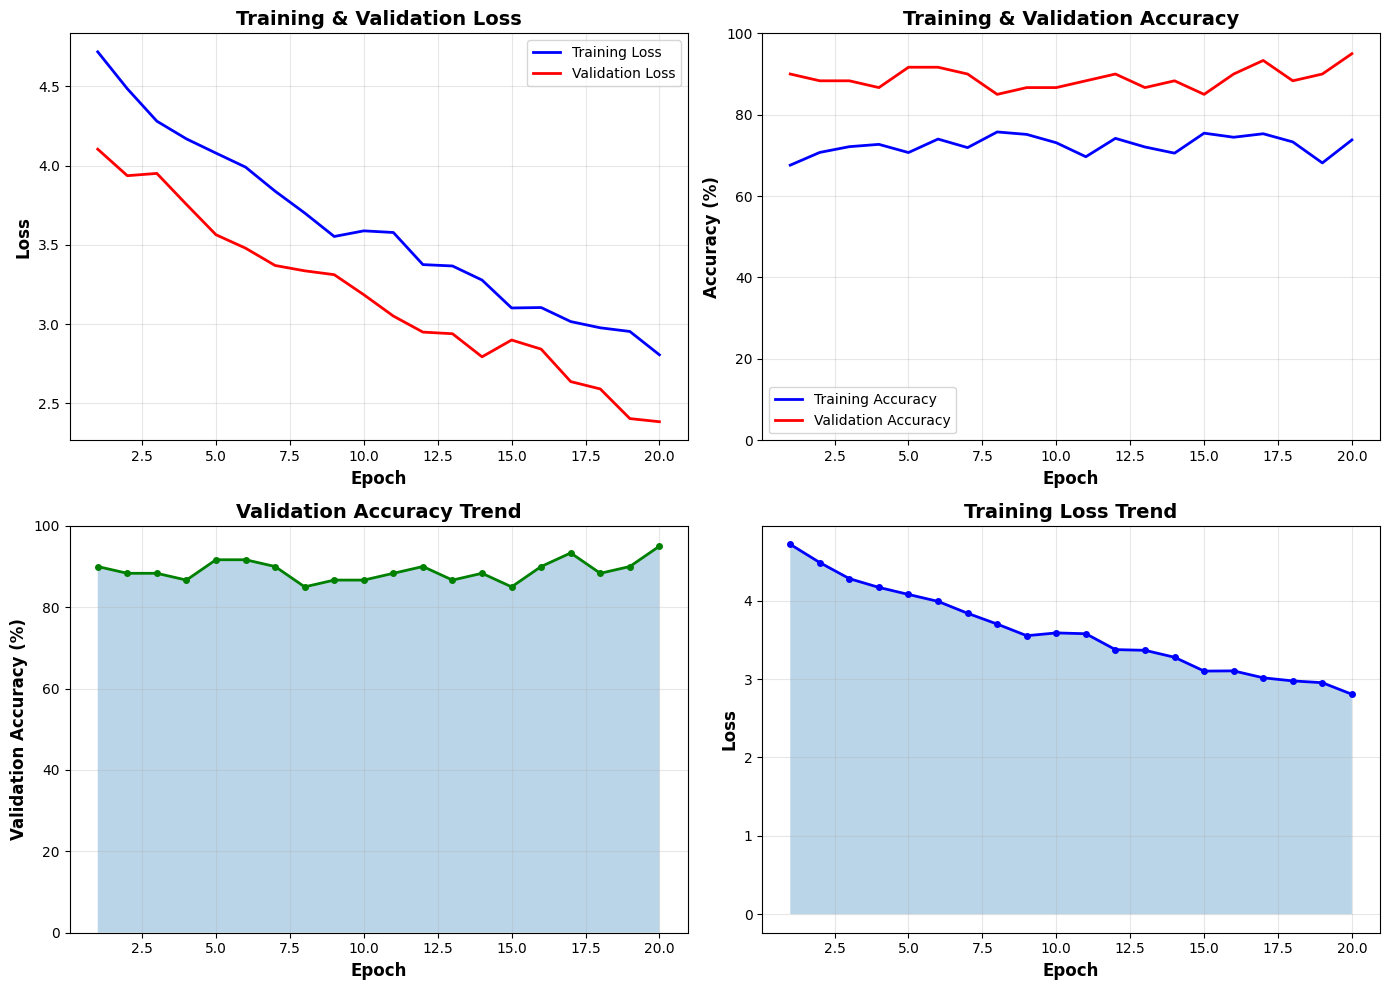


LOADING ADVERSARIAL EXAMPLES FOR EVALUATION

✓ All adversarial examples loaded


COMPARING STANDARD vs ADVERSARIALLY TRAINED MODELS

1️⃣ PERFORMANCE ON CLEAN DATA:
----------------------------------------------------------------------
Standard Model Accuracy:              85.00%
Adversarially Trained Model Accuracy: 91.67%
Difference:                           +6.67%

2️⃣ ROBUSTNESS AGAINST FGSM ATTACK:
----------------------------------------------------------------------
Standard Model Accuracy:              30.00%
Adversarially Trained Model Accuracy: 31.67%
Improvement:                          +1.67%

3️⃣ ROBUSTNESS AGAINST PGD ATTACK:
----------------------------------------------------------------------
Standard Model Accuracy:              0.00%
Adversarially Trained Model Accuracy: 5.00%
Improvement:                          +5.00%

4️⃣ ROBUSTNESS AGAINST 2D-MALAFIDE ATTACK:
----------------------------------------------------------------------
Standard Model Accuracy:       

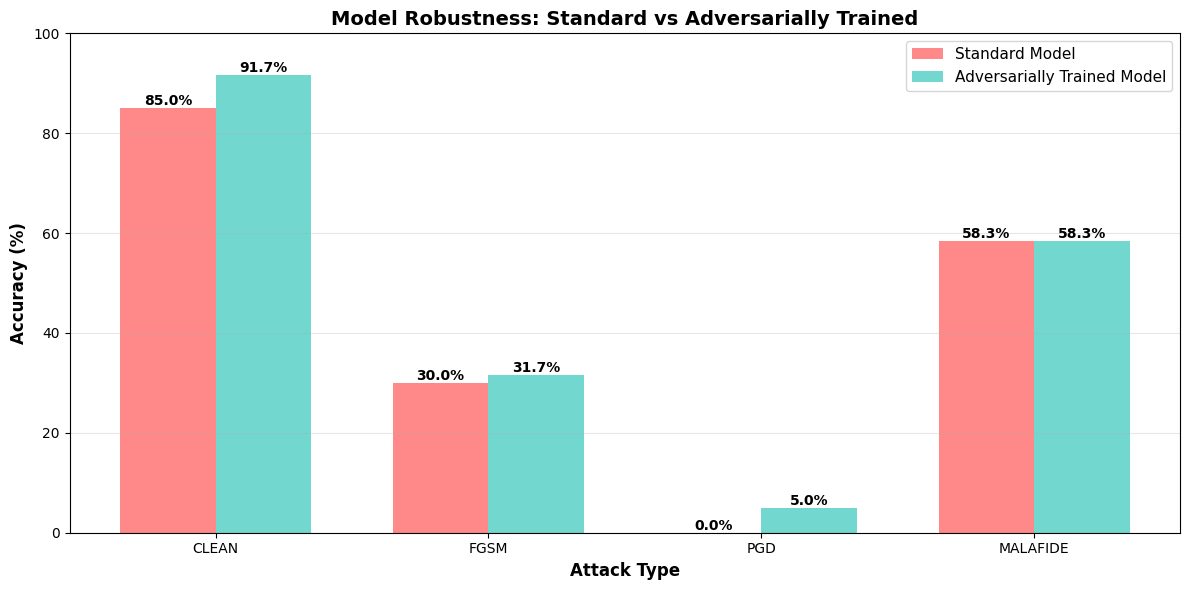


✅ ADVERSARIAL TRAINING PIPELINE COMPLETE


In [13]:
import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tqdm import tqdm
from tensorflow.keras.models import load_model
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, EarlyStopping

# ============================================================================
# DATA LOADING AND VERIFICATION
# ============================================================================

def load_training_data(work_dir):
    """
    Load preprocessed training data from .npy files.
    
    Args:
        work_dir: Working directory containing saved numpy arrays
        
    Returns:
        Dictionary containing all datasets
    """
    print("=" * 70)
    print("LOADING DATA FROM NPY FILES")
    print("=" * 70)
    
    data = {
        'X_train': np.load(os.path.join(work_dir, "X_train_augmented.npy")),
        'y_train': np.load(os.path.join(work_dir, "y_train_augmented.npy")),
        'X_test': np.load(os.path.join(work_dir, "X_test.npy")),
        'y_test': np.load(os.path.join(work_dir, "y_test.npy")),
        'X_val': np.load(os.path.join(work_dir, "X_val.npy")),
        'y_val': np.load(os.path.join(work_dir, "y_val.npy"))
    }
    
    print(f"\n✓ Data loaded successfully!")
    for key, value in data.items():
        print(f"  {key}: {value.shape}")
    print()
    
    return data


def verify_and_fix_data(X_train, y_train, X_val, y_val, X_test=None, y_test=None):
    """
    Verify and fix data types before training.
    Converts objects, strings, and incorrect types to float32.
    
    Args:
        X_train, y_train: Training data
        X_val, y_val: Validation data
        X_test, y_test: Optional test data
        
    Returns:
        Tuple of verified and fixed datasets
    """
    print("=" * 70)
    print("VERIFYING AND FIXING DATA TYPES")
    print("=" * 70)
    
    def convert_to_float32(data, name):
        """Helper to convert data to float32."""
        print(f"\n{name}:")
        print(f"   Type: {type(data)}")
        print(f"   Dtype: {data.dtype}")
        print(f"   Shape: {data.shape}")
        
        if data.dtype in [object, str, 'object']:
            print(f"   ⚠️  Converting from {data.dtype} to float32...")
            try:
                data = np.array([np.float32(x) for x in data])
            except Exception as e:
                print(f"   ❌ Conversion failed: {e}")
                return None
        else:
            data = np.asarray(data, dtype=np.float32)
        
        print(f"   ✓ Fixed to {data.dtype}")
        return data
    
    def convert_labels(labels, name):
        """Helper to convert and one-hot encode labels."""
        print(f"\n{name}:")
        print(f"   Type: {type(labels)}")
        print(f"   Dtype: {labels.dtype}")
        print(f"   Shape: {labels.shape}")
        
        if labels.dtype in [object, str, 'object']:
            print(f"   ⚠️  Converting from {labels.dtype}...")
            try:
                labels_int = np.array([int(y) for y in labels])
                if len(labels.shape) == 1:
                    labels = tf.keras.utils.to_categorical(labels_int, 2)
                else:
                    labels = np.float32(labels)
            except Exception as e:
                print(f"   ❌ Conversion failed: {e}")
                return None
        else:
            labels = np.asarray(labels, dtype=np.float32)
        
        print(f"   ✓ Fixed to {labels.dtype}")
        return labels
    
    # Convert all datasets
    X_train = convert_to_float32(X_train, "1️⃣ X_train")
    y_train = convert_labels(y_train, "2️⃣ y_train")
    X_val = convert_to_float32(X_val, "3️⃣ X_val")
    y_val = convert_labels(y_val, "4️⃣ y_val")
    
    if X_test is not None:
        X_test = convert_to_float32(X_test, "5️⃣ X_test")
    if y_test is not None:
        y_test = convert_labels(y_test, "6️⃣ y_test")
    
    # Check if any conversion failed - FIXED LINE
    if any(x is None for x in [X_train, y_train, X_val, y_val]):
        print(f"\n{'=' * 70}")
        print("❌ DATA VERIFICATION FAILED")
        print(f"{'=' * 70}\n")
        return None, None, None, None, None, None
    
    print(f"\n{'=' * 70}")
    print("✓ ALL DATA VERIFIED AND FIXED")
    print(f"{'=' * 70}\n")
    
    return X_train, y_train, X_val, y_val, X_test, y_test



def load_malafide_filter(work_dir, malafide_attacker):
    """
    Load pre-trained 2D-Malafide filter.
    
    Args:
        work_dir: Directory containing the filter
        malafide_attacker: Malafide2DAttack instance
        
    Returns:
        Updated malafide_attacker with loaded filter
    """
    print("=" * 70)
    print("LOADING PRE-TRAINED 2D-MALAFIDE FILTER")
    print("=" * 70)
    
    try:
        trained_filter = np.load(os.path.join(work_dir, 'malafide_filter_trained.npy'))
        malafide_attacker.filter = tf.Variable(trained_filter, dtype=tf.float32, trainable=True)
        print(f"\n✓ Loaded pre-trained 2D-Malafide filter")
        print(f"  Filter shape: {malafide_attacker.filter.shape}")
        print(f"  Filter dtype: {malafide_attacker.filter.dtype}")
    except FileNotFoundError:
        print(f"\n⚠️  WARNING: Pre-trained filter not found!")
        print(f"   Expected: {os.path.join(work_dir, 'malafide_filter_trained.npy')}")
        print(f"   Please run the 2D-Malafide attack first to generate the filter.")
        print(f"   Initializing new filter for now...")
        malafide_attacker.initialize_filter(num_channels=3)
    
    print("=" * 70 + "\n")
    return malafide_attacker


# ============================================================================
# ADVERSARIAL ATTACK GENERATION
# ============================================================================

def generate_adversarial_batch(model, images, labels, attack_type='malafide', 
                               epsilon=0.03, malafide_attacker=None):
    """
    Generate adversarial examples during training.
    
    Args:
        model: Target model
        images: Batch of images (float32)
        labels: Batch of labels (one-hot encoded, float32)
        attack_type: 'fgsm', 'pgd', or 'malafide'
        epsilon: Perturbation magnitude
        malafide_attacker: Malafide2DAttack instance (required for malafide)
        
    Returns:
        Adversarial images as numpy array
    """
    images = tf.cast(images, tf.float32)
    labels = tf.cast(labels, tf.float32)
    
    if attack_type == 'fgsm':
        return fgsm_attack(model, images, labels, epsilon)
    elif attack_type == 'pgd':
        return pgd_attack(model, images, labels, epsilon, alpha=0.01, num_iter=5)
    elif attack_type == 'malafide':
        if malafide_attacker is None:
            raise ValueError("malafide_attacker must be provided for malafide attack")
        adversarial_images = malafide_attacker.apply_filter(images)
        return adversarial_images.numpy() if isinstance(adversarial_images, tf.Tensor) else adversarial_images
    else:
        raise ValueError(f"Unknown attack type: {attack_type}")


# ============================================================================
# ADVERSARIAL TRAINING
# ============================================================================

def adversarial_training(model, X_train, y_train, X_val, y_val,
                        epochs=20, batch_size=8, epsilon=0.03,
                        adv_ratio=0.5, attack_type='malafide', 
                        malafide_attacker=None):
    """
    Train model with adversarial examples to improve robustness.
    
    Args:
        model: Model to train
        X_train, y_train: Training data (float32)
        X_val, y_val: Validation data (float32)
        epochs: Number of training epochs
        batch_size: Batch size
        epsilon: Perturbation magnitude
        adv_ratio: Ratio of adversarial examples in each batch (0.0-1.0)
        attack_type: 'fgsm', 'pgd', or 'malafide'
        malafide_attacker: Malafide2DAttack instance (for malafide attack)
        
    Returns:
        model: Trained model
        history_data: Training history dictionary
    """
    print(f"\n{'=' * 70}")
    print("ADVERSARIAL TRAINING - ROBUSTNESS ENHANCEMENT")
    print(f"{'=' * 70}")
    print(f"\nConfiguration:")
    print(f"  Attack Type: {attack_type.upper()}")
    print(f"  Epsilon: {epsilon}")
    print(f"  Adversarial Ratio: {adv_ratio * 100}%")
    print(f"  Epochs: {epochs}")
    print(f"  Batch Size: {batch_size}")
    print(f"  Training Samples: {len(X_train)}")
    print(f"  Validation Samples: {len(X_val)}")
    print(f"{'=' * 70}\n")
    
    # Training history
    history_data = {
        'loss': [],
        'accuracy': [],
        'val_loss': [],
        'val_accuracy': []
    }
    
    best_val_acc = 0
    patience_counter = 0
    max_patience = 15
    
    for epoch in range(epochs):
        print(f"\n{'=' * 70}")
        print(f"Epoch {epoch+1}/{epochs}")
        print(f"{'=' * 70}")
        
        # Shuffle training data
        indices = np.random.permutation(len(X_train))
        X_train_shuffled = X_train[indices]
        y_train_shuffled = y_train[indices]
        
        epoch_losses = []
        epoch_accs = []
        total_adv_samples = 0
        total_clean_samples = 0
        
        # Train on batches
        pbar = tqdm(range(0, len(X_train), batch_size),
                   desc=f"Training (adv_ratio={adv_ratio*100}%)")
        
        for i in pbar:
            batch_X = X_train_shuffled[i:i+batch_size].copy()
            batch_y = y_train_shuffled[i:i+batch_size].copy()
            
            # Determine adversarial/clean split
            num_adv = int(len(batch_X) * adv_ratio)
            num_clean = len(batch_X) - num_adv
            
            if num_adv > 0:
                try:
                    # Generate adversarial examples
                    adv_X = generate_adversarial_batch(
                        model, batch_X[:num_adv], batch_y[:num_adv],
                        attack_type=attack_type, epsilon=epsilon, 
                        malafide_attacker=malafide_attacker
                    )
                    
                    # Combine clean and adversarial
                    combined_X = np.concatenate([batch_X[num_adv:], adv_X], axis=0)
                    combined_y = np.concatenate([batch_y[num_adv:], batch_y[:num_adv]], axis=0)
                    
                    total_adv_samples += num_adv
                    total_clean_samples += num_clean
                    
                except Exception as e:
                    print(f"\n⚠️  Warning: Could not generate adversarial examples")
                    print(f"   Error: {str(e)[:50]}")
                    print(f"   Falling back to clean batch")
                    combined_X = batch_X
                    combined_y = batch_y
                    total_clean_samples += len(batch_X)
            else:
                combined_X = batch_X
                combined_y = batch_y
                total_clean_samples += len(batch_X)
            
            # Ensure float32
            combined_X = np.asarray(combined_X, dtype=np.float32)
            combined_y = np.asarray(combined_y, dtype=np.float32)
            
            # Train on batch
            try:
                batch_history = model.train_on_batch(combined_X, combined_y)
                
                # Handle different return types
                if isinstance(batch_history, (list, tuple)):
                    loss_val = float(batch_history[0]) if len(batch_history) > 0 else 0.0
                    acc_val = float(batch_history[1]) if len(batch_history) > 1 else 0.0
                else:
                    loss_val = float(batch_history)
                    acc_val = 0.0
                
                epoch_losses.append(loss_val)
                epoch_accs.append(acc_val)
                
                pbar.set_postfix({
                    'loss': f"{np.mean(epoch_losses):.4f}",
                    'acc': f"{np.mean(epoch_accs):.4f}"
                })
            except Exception as e:
                print(f"\n❌ Error during batch training: {str(e)[:100]}")
                continue
        
        # Calculate epoch statistics
        epoch_loss = np.mean(epoch_losses) if epoch_losses else 0.0
        epoch_acc = np.mean(epoch_accs) if epoch_accs else 0.0
        
        # Validation
        try:
            X_val_check = np.asarray(X_val, dtype=np.float32)
            y_val_check = np.asarray(y_val, dtype=np.float32)
            
            val_history = model.evaluate(X_val_check, y_val_check, verbose=0)
            
            # Parse validation results
            if isinstance(val_history, (list, tuple)):
                val_loss = float(val_history[0]) if len(val_history) >= 1 else 0.0
                val_acc = float(val_history[1]) if len(val_history) >= 2 else 0.0
            elif isinstance(val_history, dict):
                val_loss = float(val_history.get('loss', 0.0))
                val_acc = float(val_history.get('accuracy', 0.0))
            else:
                val_loss = float(val_history)
                val_acc = 0.0
                
        except Exception as e:
            print(f"❌ Error during validation: {str(e)[:100]}")
            val_loss, val_acc = 0.0, 0.0
        
        # Record history
        history_data['loss'].append(epoch_loss)
        history_data['accuracy'].append(epoch_acc)
        history_data['val_loss'].append(val_loss)
        history_data['val_accuracy'].append(val_acc)
        
        # Print epoch results
        print(f"\n📊 Epoch Results:")
        print(f"  Training Loss:         {epoch_loss:.4f}")
        print(f"  Training Accuracy:     {epoch_acc * 100:.2f}%")
        print(f"  Validation Loss:       {val_loss:.4f}")
        print(f"  Validation Accuracy:   {val_acc * 100:.2f}%")
        print(f"  Clean Samples:         {total_clean_samples}")
        print(f"  Adversarial Samples:   {total_adv_samples}")
        
        # Track best model and early stopping
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            patience_counter = 0
            print(f"\n✅ New best validation accuracy: {val_acc * 100:.2f}%")
        else:
            patience_counter += 1
            if patience_counter >= max_patience:
                print(f"\n⚠️  Early stopping after {epoch+1} epochs")
                print(f"   (No improvement for {max_patience} consecutive epochs)")
                break
    
    print(f"\n{'=' * 70}")
    print("ADVERSARIAL TRAINING COMPLETE")
    print(f"{'=' * 70}")
    print(f"\nFinal Results:")
    print(f"  Best Validation Accuracy:  {best_val_acc * 100:.2f}%")
    print(f"  Final Training Accuracy:   {epoch_acc * 100:.2f}%")
    print(f"  Final Validation Accuracy: {val_acc * 100:.2f}%")
    print(f"  Total Epochs Completed:    {epoch+1}")
    print(f"{'=' * 70}\n")
    
    return model, history_data


# ============================================================================
# EVALUATION AND COMPARISON
# ============================================================================

def evaluate_adversarial_training(model_standard, model_adv, X_test, y_test,
                                  X_adv_fgsm, X_adv_pgd, X_adv_malafide):
    """
    Compare standard model vs adversarially trained model.
    
    Args:
        model_standard: Original model
        model_adv: Adversarially trained model
        X_test: Clean test data
        y_test: Test labels
        X_adv_fgsm: FGSM adversarial examples
        X_adv_pgd: PGD adversarial examples
        X_adv_malafide: 2D-Malafide adversarial examples
        
    Returns:
        Dictionary containing comparison results
    """
    print(f"\n{'=' * 70}")
    print("COMPARING STANDARD vs ADVERSARIALLY TRAINED MODELS")
    print(f"{'=' * 70}\n")
    
    # Ensure float32
    X_test = np.asarray(X_test, dtype=np.float32)
    y_test = np.asarray(y_test, dtype=np.float32)
    X_adv_fgsm = np.asarray(X_adv_fgsm, dtype=np.float32)
    X_adv_pgd = np.asarray(X_adv_pgd, dtype=np.float32)
    X_adv_malafide = np.asarray(X_adv_malafide, dtype=np.float32)
    
    # Test on clean data
    print("1️⃣ PERFORMANCE ON CLEAN DATA:")
    print("-" * 70)
    std_clean_loss, std_clean_acc = model_standard.evaluate(X_test, y_test, verbose=0)
    adv_clean_loss, adv_clean_acc = model_adv.evaluate(X_test, y_test, verbose=0)
    print(f"Standard Model Accuracy:              {std_clean_acc * 100:.2f}%")
    print(f"Adversarially Trained Model Accuracy: {adv_clean_acc * 100:.2f}%")
    print(f"Difference:                           {(adv_clean_acc - std_clean_acc) * 100:+.2f}%")
    
    # Test on FGSM
    print(f"\n2️⃣ ROBUSTNESS AGAINST FGSM ATTACK:")
    print("-" * 70)
    std_fgsm_loss, std_fgsm_acc = model_standard.evaluate(X_adv_fgsm, y_test, verbose=0)
    adv_fgsm_loss, adv_fgsm_acc = model_adv.evaluate(X_adv_fgsm, y_test, verbose=0)
    print(f"Standard Model Accuracy:              {std_fgsm_acc * 100:.2f}%")
    print(f"Adversarially Trained Model Accuracy: {adv_fgsm_acc * 100:.2f}%")
    print(f"Improvement:                          {(adv_fgsm_acc - std_fgsm_acc) * 100:+.2f}%")
    
    # Test on PGD
    print(f"\n3️⃣ ROBUSTNESS AGAINST PGD ATTACK:")
    print("-" * 70)
    std_pgd_loss, std_pgd_acc = model_standard.evaluate(X_adv_pgd, y_test, verbose=0)
    adv_pgd_loss, adv_pgd_acc = model_adv.evaluate(X_adv_pgd, y_test, verbose=0)
    print(f"Standard Model Accuracy:              {std_pgd_acc * 100:.2f}%")
    print(f"Adversarially Trained Model Accuracy: {adv_pgd_acc * 100:.2f}%")
    print(f"Improvement:                          {(adv_pgd_acc - std_pgd_acc) * 100:+.2f}%")
    
    # Test on 2D-Malafide
    print(f"\n4️⃣ ROBUSTNESS AGAINST 2D-MALAFIDE ATTACK:")
    print("-" * 70)
    std_mal_loss, std_mal_acc = model_standard.evaluate(X_adv_malafide, y_test, verbose=0)
    adv_mal_loss, adv_mal_acc = model_adv.evaluate(X_adv_malafide, y_test, verbose=0)
    print(f"Standard Model Accuracy:              {std_mal_acc * 100:.2f}%")
    print(f"Adversarially Trained Model Accuracy: {adv_mal_acc * 100:.2f}%")
    print(f"Improvement:                          {(adv_mal_acc - std_mal_acc) * 100:+.2f}%")
    
    print(f"\n{'=' * 70}")
    print("EVALUATION COMPLETE")
    print(f"{'=' * 70}\n")
    
    return {
        'clean': {'std': std_clean_acc, 'adv': adv_clean_acc},
        'fgsm': {'std': std_fgsm_acc, 'adv': adv_fgsm_acc},
        'pgd': {'std': std_pgd_acc, 'adv': adv_pgd_acc},
        'malafide': {'std': std_mal_acc, 'adv': adv_mal_acc}
    }


# ============================================================================
# VISUALIZATION
# ============================================================================

def plot_adversarial_training_history(history_data, save_path=None):
    """Plot adversarial training history."""
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    epochs = range(1, len(history_data['loss']) + 1)
    
    # Plot 1: Loss
    axes[0, 0].plot(epochs, history_data['loss'], 'b-', label='Training Loss', linewidth=2)
    axes[0, 0].plot(epochs, history_data['val_loss'], 'r-', label='Validation Loss', linewidth=2)
    axes[0, 0].set_xlabel('Epoch', fontsize=12, fontweight='bold')
    axes[0, 0].set_ylabel('Loss', fontsize=12, fontweight='bold')
    axes[0, 0].set_title('Training & Validation Loss', fontsize=14, fontweight='bold')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    # Plot 2: Accuracy
    axes[0, 1].plot(epochs, [acc*100 for acc in history_data['accuracy']], 
                   'b-', label='Training Accuracy', linewidth=2)
    axes[0, 1].plot(epochs, [acc*100 for acc in history_data['val_accuracy']], 
                   'r-', label='Validation Accuracy', linewidth=2)
    axes[0, 1].set_xlabel('Epoch', fontsize=12, fontweight='bold')
    axes[0, 1].set_ylabel('Accuracy (%)', fontsize=12, fontweight='bold')
    axes[0, 1].set_title('Training & Validation Accuracy', fontsize=14, fontweight='bold')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
    axes[0, 1].set_ylim([0, 100])
    
    # Plot 3: Validation trend
    axes[1, 0].plot(epochs, [acc*100 for acc in history_data['val_accuracy']], 
                   'g-o', linewidth=2, markersize=4)
    axes[1, 0].set_xlabel('Epoch', fontsize=12, fontweight='bold')
    axes[1, 0].set_ylabel('Validation Accuracy (%)', fontsize=12, fontweight='bold')
    axes[1, 0].set_title('Validation Accuracy Trend', fontsize=14, fontweight='bold')
    axes[1, 0].grid(True, alpha=0.3)
    axes[1, 0].fill_between(epochs, [acc*100 for acc in history_data['val_accuracy']], alpha=0.3)
    axes[1, 0].set_ylim([0, 100])
    
    # Plot 4: Training loss trend
    axes[1, 1].plot(epochs, history_data['loss'], 'b-o', label='Training Loss', 
                   linewidth=2, markersize=4)
    axes[1, 1].set_xlabel('Epoch', fontsize=12, fontweight='bold')
    axes[1, 1].set_ylabel('Loss', fontsize=12, fontweight='bold')
    axes[1, 1].set_title('Training Loss Trend', fontsize=14, fontweight='bold')
    axes[1, 1].grid(True, alpha=0.3)
    axes[1, 1].fill_between(epochs, history_data['loss'], alpha=0.3)
    
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"✓ Training history plot saved to {save_path}")
    plt.show()


def plot_robustness_comparison(results, save_path=None):
    """Plot robustness comparison between standard and adversarial models."""
    attack_types = list(results.keys())
    std_accuracies = [results[attack]['std'] * 100 for attack in attack_types]
    adv_accuracies = [results[attack]['adv'] * 100 for attack in attack_types]
    
    x = np.arange(len(attack_types))
    width = 0.35
    
    fig, ax = plt.subplots(figsize=(12, 6))
    
    bars1 = ax.bar(x - width/2, std_accuracies, width, 
                   label='Standard Model', alpha=0.8, color='#FF6B6B')
    bars2 = ax.bar(x + width/2, adv_accuracies, width, 
                   label='Adversarially Trained Model', alpha=0.8, color='#4ECDC4')
    
    ax.set_xlabel('Attack Type', fontsize=12, fontweight='bold')
    ax.set_ylabel('Accuracy (%)', fontsize=12, fontweight='bold')
    ax.set_title('Model Robustness: Standard vs Adversarially Trained', 
                fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels([t.upper() for t in attack_types])
    ax.legend(fontsize=11)
    ax.set_ylim([0, 100])
    ax.grid(axis='y', alpha=0.3)
    
    # Add value labels on bars
    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height,
                   f'{height:.1f}%',
                   ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"✓ Robustness comparison plot saved to {save_path}")
    plt.show()


# ============================================================================
# MAIN EXECUTION
# ============================================================================

if __name__ == "__main__":
    WORK_DIR = "./working"
    
    # Load data
    data = load_training_data(WORK_DIR)
    
    # Verify and fix data types
    X_train, y_train, X_val, y_val, X_test, y_test = verify_and_fix_data(
        data['X_train'], data['y_train'], 
        data['X_val'], data['y_val'],
        data['X_test'], data['y_test']
    )
    
    if X_train is None:
        print("❌ DATA VERIFICATION FAILED - Cannot proceed")
        exit(1)
    
    # Load Malafide filter
    malafide_attacker = Malafide2DAttack(filter_size=3, learning_rate=0.01, num_iterations=100)
    malafide_attacker = load_malafide_filter(WORK_DIR, malafide_attacker)
    
    # Load models
    print("\n" + "=" * 70)
    print("LOADING MODELS")
    print("=" * 70 + "\n")
    
    try:
        model_standard = load_model(os.path.join(WORK_DIR, "deepfake_detection_best.keras"))
        print("✓ Standard model loaded\n")
    except Exception as e:
        print(f"❌ Error loading standard model: {e}\n")
        model_standard = None
    
    try:
        model_adv_trained = load_model(os.path.join(WORK_DIR, "deepfake_detection_best.keras"))
        print("✓ Model for adversarial training loaded\n")
    except Exception as e:
        print(f"❌ Error loading model for training: {e}\n")
        model_adv_trained = None
        exit(1)
    
    # Run adversarial training
    print("=" * 70)
    print("STARTING ADVERSARIAL TRAINING")
    print("=" * 70 + "\n")
    
    model_adv_trained, adv_history = adversarial_training(
        model=model_adv_trained,
        X_train=X_train,
        y_train=y_train,
        X_val=X_val,
        y_val=y_val,
        epochs=20,
        batch_size=8,
        epsilon=0.03,
        adv_ratio=0.5,  # 50% adversarial examples
        attack_type='malafide',
        malafide_attacker=malafide_attacker
    )
    
    # Save adversarially trained model
    print(f"\n{'=' * 70}")
    print("SAVING ADVERSARIALLY TRAINED MODEL")
    print(f"{'=' * 70}")
    save_path = os.path.join(WORK_DIR, "deepfake_adv_trained_final.keras")
    model_adv_trained.save(save_path)
    print(f"✓ Model saved to {save_path}\n")
    
    # Plot training history
    print("=" * 70)
    print("GENERATING VISUALIZATIONS")
    print("=" * 70 + "\n")
    plot_adversarial_training_history(
        adv_history,
        save_path=os.path.join(WORK_DIR, 'adversarial_training_history.png')
    )
    
    # Evaluate and compare models
    if model_standard is not None:
        print("\n" + "=" * 70)
        print("LOADING ADVERSARIAL EXAMPLES FOR EVALUATION")
        print("=" * 70 + "\n")
        
        try:
            X_adv_fgsm = np.load(os.path.join(WORK_DIR, 'X_test_fgsm_adversarial.npy'))
            X_adv_pgd = np.load(os.path.join(WORK_DIR, 'X_test_pgd_adversarial.npy'))
            X_adv_malafide = np.load(os.path.join(WORK_DIR, 'X_test_malafide_adversarial.npy'))
            print("✓ All adversarial examples loaded\n")
            
            # Compare models
            results = evaluate_adversarial_training(
                model_standard=model_standard,
                model_adv=model_adv_trained,
                X_test=X_test,
                y_test=y_test,
                X_adv_fgsm=X_adv_fgsm,
                X_adv_pgd=X_adv_pgd,
                X_adv_malafide=X_adv_malafide
            )
            
            # Plot comparison
            print("\n" + "=" * 70)
            print("GENERATING COMPARISON PLOTS")
            print("=" * 70 + "\n")
            plot_robustness_comparison(
                results,
                save_path=os.path.join(WORK_DIR, 'robustness_comparison.png')
            )
            
        except FileNotFoundError as e:
            print(f"⚠️  Adversarial example files not found: {e}")
            print("   Please run FGSM, PGD, and 2D-Malafide attacks first")
    else:
        print("⚠️  Standard model not available for comparison")
    
    print("\n" + "=" * 70)
    print("✅ ADVERSARIAL TRAINING PIPELINE COMPLETE")
    print("=" * 70)

MODEL EVALUATION AND COMPARISON

LOADING MODELS
✓ Standard model loaded
✓ Adversarially trained model loaded

LOADING TEST DATA
✓ Test data loaded
  X_test shape: (60, 10, 128, 128, 3)
  y_test shape: (60, 2)

LOADING ADVERSARIAL EXAMPLES
✓ FGSM examples loaded ((60, 10, 128, 128, 3))
✓ PGD examples loaded ((60, 10, 128, 128, 3))
✓ MALAFIDE examples loaded ((60, 10, 128, 128, 3))

FILE STATUS SUMMARY
  FGSM           : ✓
  PGD            : ✓
  MALAFIDE       : ✓

✓ Successfully loaded 3 adversarial example files

EVALUATING MODEL ROBUSTNESS

📊 CLEAN DATA (No Attack):
----------------------------------------------------------------------
Standard Model:              85.00%
Adversarially Trained Model: 91.67%
Difference:                  +6.67%

📊 FGSM ADVERSARIAL ATTACK:
----------------------------------------------------------------------
Standard Model:              30.00%
Adversarially Trained Model: 31.67%
Absolute Improvement:        +1.67 percentage points
Relative Improvement:  

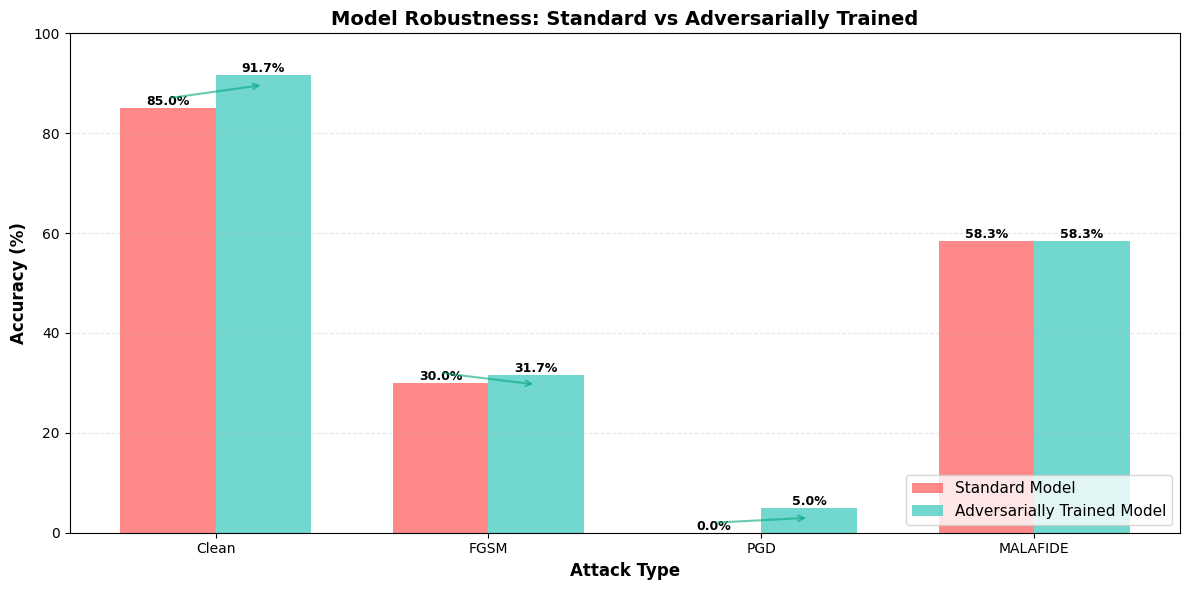


SUMMARY REPORT

Improvement Summary:
----------------------------------------------------------------------

FGSM:
  Before Training:  30.00%
  After Training:   31.67%
  Improvement:      +1.67 percentage points
  Status:           🟡 MODEST

PGD:
  Before Training:  0.00%
  After Training:   5.00%
  Improvement:      +5.00 percentage points
  Status:           🟡 MODEST

MALAFIDE:
  Before Training:  58.33%
  After Training:   58.33%
  Improvement:      +0.00 percentage points
  Status:           🔴 LIMITED

----------------------------------------------------------------------
OVERALL ASSESSMENT:
  Average Improvement: +2.22 percentage points
  Overall Grade: ⭐ NEEDS IMPROVEMENT

✅ EVALUATION COMPLETE

Results saved to: ./working
  - Comparison plot: robustness_comparison_final.png

Next steps:
  - Review the improvement percentages
  - Analyze which attacks show the most improvement
  - Consider further training if results are suboptimal


In [14]:
import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model

# ============================================================================
# CONFIGURATION
# ============================================================================

WORK_DIR = "./working"  # Change if different

# ============================================================================
# DATA LOADING FUNCTIONS
# ============================================================================

def load_models(work_dir):
    """
    Load standard and adversarially trained models.
    
    Args:
        work_dir: Directory containing saved models
        
    Returns:
        Tuple of (model_standard, model_adv_trained)
    """
    print("\n" + "=" * 70)
    print("LOADING MODELS")
    print("=" * 70)
    
    model_standard = None
    model_adv_trained = None
    
    # Load standard model
    try:
        model_standard = load_model(os.path.join(work_dir, "deepfake_detection_best.keras"))
        print("✓ Standard model loaded")
    except Exception as e:
        print(f"❌ Error loading standard model: {e}")
    
    # Load adversarially trained model
    try:
        model_adv_trained = load_model(os.path.join(work_dir, "deepfake_adv_trained_final.keras"))
        print("✓ Adversarially trained model loaded")
    except Exception as e:
        print(f"❌ Error loading adversarially trained model: {e}")
    
    return model_standard, model_adv_trained


def load_test_data(work_dir):
    """
    Load test dataset.
    
    Args:
        work_dir: Directory containing test data
        
    Returns:
        Tuple of (X_test, y_test)
    """
    print("\n" + "=" * 70)
    print("LOADING TEST DATA")
    print("=" * 70)
    
    try:
        X_test = np.load(os.path.join(work_dir, "X_test.npy"))
        y_test = np.load(os.path.join(work_dir, "y_test.npy"))
        print(f"✓ Test data loaded")
        print(f"  X_test shape: {X_test.shape}")
        print(f"  y_test shape: {y_test.shape}")
        return X_test, y_test
    except Exception as e:
        print(f"❌ Error loading test data: {e}")
        return None, None


def load_adversarial_examples(work_dir):
    """
    Load all available adversarial examples.
    
    Args:
        work_dir: Directory containing adversarial examples
        
    Returns:
        Dictionary of attack_name -> adversarial_examples
    """
    print("\n" + "=" * 70)
    print("LOADING ADVERSARIAL EXAMPLES")
    print("=" * 70)
    
    adversarial_examples = {}
    files_status = {}
    
    # Define attack files to load
    attack_files = {
        'fgsm': 'X_test_fgsm_adversarial.npy',
        'pgd': 'X_test_pgd_adversarial.npy',
        'malafide': 'X_test_malafide_adversarial.npy'
    }
    
    # Attempt to load each file
    for attack_name, filename in attack_files.items():
        filepath = os.path.join(work_dir, filename)
        try:
            X_adv = np.load(filepath)
            adversarial_examples[attack_name] = X_adv
            files_status[attack_name.upper()] = '✓'
            print(f"✓ {attack_name.upper()} examples loaded ({X_adv.shape})")
        except FileNotFoundError:
            files_status[attack_name.upper()] = '✗ MISSING'
            print(f"✗ {attack_name.upper()} examples MISSING")
    
    # Print summary
    print("\n" + "=" * 70)
    print("FILE STATUS SUMMARY")
    print("=" * 70)
    for attack_type, status in files_status.items():
        print(f"  {attack_type:15s}: {status}")
    
    if len(adversarial_examples) == 0:
        print("\n❌ ERROR: No adversarial examples found!")
        print("\nPlease ensure you have run:")
        print("  1. FGSM attack (creates X_test_fgsm_adversarial.npy)")
        print("  2. PGD attack (creates X_test_pgd_adversarial.npy)")
        print("  3. 2D-Malafide attack (creates X_test_malafide_adversarial.npy)")
    else:
        print(f"\n✓ Successfully loaded {len(adversarial_examples)} adversarial example files")
    
    return adversarial_examples


# ============================================================================
# EVALUATION FUNCTIONS
# ============================================================================

def evaluate_models(model_std, model_adv, X_test, y_test, adv_examples):
    """
    Evaluate and compare standard vs adversarially trained models.
    
    Args:
        model_std: Standard (baseline) model
        model_adv: Adversarially trained model
        X_test: Clean test images
        y_test: Test labels
        adv_examples: Dictionary of attack_name -> adversarial_examples
        
    Returns:
        Dictionary containing evaluation results for all attacks
    """
    print("\n" + "=" * 70)
    print("EVALUATING MODEL ROBUSTNESS")
    print("=" * 70)
    
    results = {}
    
    # Evaluate on clean data (baseline)
    print("\n📊 CLEAN DATA (No Attack):")
    print("-" * 70)
    
    try:
        std_clean_loss, std_clean_acc = model_std.evaluate(X_test, y_test, verbose=0)
        adv_clean_loss, adv_clean_acc = model_adv.evaluate(X_test, y_test, verbose=0)
        
        print(f"Standard Model:              {std_clean_acc * 100:.2f}%")
        print(f"Adversarially Trained Model: {adv_clean_acc * 100:.2f}%")
        print(f"Difference:                  {(adv_clean_acc - std_clean_acc) * 100:+.2f}%")
        
        results['clean'] = {
            'std': std_clean_acc,
            'adv': adv_clean_acc
        }
    except Exception as e:
        print(f"❌ Error evaluating clean data: {e}")
    
    # Evaluate on adversarial examples
    for attack_name, X_adv in adv_examples.items():
        attack_display = attack_name.upper()
        print(f"\n📊 {attack_display} ADVERSARIAL ATTACK:")
        print("-" * 70)
        
        try:
            std_adv_loss, std_adv_acc = model_std.evaluate(X_adv, y_test, verbose=0)
            adv_adv_loss, adv_adv_acc = model_adv.evaluate(X_adv, y_test, verbose=0)
            
            absolute_improvement = adv_adv_acc - std_adv_acc
            relative_improvement = (absolute_improvement / std_adv_acc * 100) if std_adv_acc > 0 else 0
            
            print(f"Standard Model:              {std_adv_acc * 100:.2f}%")
            print(f"Adversarially Trained Model: {adv_adv_acc * 100:.2f}%")
            print(f"Absolute Improvement:        {absolute_improvement * 100:+.2f} percentage points")
            print(f"Relative Improvement:        {relative_improvement:+.1f}%")
            
            results[attack_name] = {
                'std': std_adv_acc,
                'adv': adv_adv_acc
            }
        except Exception as e:
            print(f"❌ Error evaluating {attack_name}: {e}")
    
    return results


# ============================================================================
# VISUALIZATION FUNCTIONS
# ============================================================================

def plot_robustness_comparison(results, save_path):
    """
    Create bar chart comparing standard vs adversarially trained models.
    
    Args:
        results: Dictionary of evaluation results
        save_path: Path to save the plot
    """
    print("\n" + "=" * 70)
    print("CREATING COMPARISON PLOT")
    print("=" * 70)
    
    try:
        attack_types = list(results.keys())
        std_accuracies = [results[attack]['std'] * 100 for attack in attack_types]
        adv_accuracies = [results[attack]['adv'] * 100 for attack in attack_types]
        
        x = np.arange(len(attack_types))
        width = 0.35
        
        fig, ax = plt.subplots(figsize=(12, 6))
        
        # Create bars
        bars1 = ax.bar(x - width/2, std_accuracies, width,
                      label='Standard Model', alpha=0.8, color='#FF6B6B')
        bars2 = ax.bar(x + width/2, adv_accuracies, width,
                      label='Adversarially Trained Model', alpha=0.8, color='#4ECDC4')
        
        # Styling
        ax.set_xlabel('Attack Type', fontsize=12, fontweight='bold')
        ax.set_ylabel('Accuracy (%)', fontsize=12, fontweight='bold')
        ax.set_title('Model Robustness: Standard vs Adversarially Trained',
                    fontsize=14, fontweight='bold')
        ax.set_xticks(x)
        ax.set_xticklabels([t.upper() if t != 'clean' else 'Clean' for t in attack_types])
        ax.legend(fontsize=11, loc='lower right')
        ax.set_ylim([0, 100])
        ax.grid(axis='y', alpha=0.3, linestyle='--')
        
        # Add value labels on bars
        for bars in [bars1, bars2]:
            for bar in bars:
                height = bar.get_height()
                ax.text(bar.get_x() + bar.get_width()/2., height,
                       f'{height:.1f}%',
                       ha='center', va='bottom', fontsize=9, fontweight='bold')
        
        # Add improvement arrows
        for i, attack in enumerate(attack_types):
            std_acc = results[attack]['std'] * 100
            adv_acc = results[attack]['adv'] * 100
            if adv_acc > std_acc:
                arrow_color = '#06A77D'
                ax.annotate('', xy=(i + width/2, adv_acc - 2), 
                           xytext=(i - width/2, std_acc + 2),
                           arrowprops=dict(arrowstyle='->', color=arrow_color, 
                                         lw=1.5, alpha=0.6))
        
        plt.tight_layout()
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"✓ Plot saved to {save_path}")
        plt.show()
        
    except Exception as e:
        print(f"❌ Error creating plot: {e}")


def print_summary_report(results):
    """
    Print detailed summary report of improvements.
    
    Args:
        results: Dictionary of evaluation results
    """
    print("\n" + "=" * 70)
    print("SUMMARY REPORT")
    print("=" * 70)
    
    print("\nImprovement Summary:")
    print("-" * 70)
    
    for attack_name in results.keys():
        if attack_name != 'clean':
            std_acc = results[attack_name]['std'] * 100
            adv_acc = results[attack_name]['adv'] * 100
            improvement = adv_acc - std_acc
            
            # Determine status
            if improvement > 30:
                status = "🟢 EXCELLENT"
            elif improvement > 20:
                status = "🟢 VERY GOOD"
            elif improvement > 10:
                status = "🟡 GOOD"
            elif improvement > 0:
                status = "🟡 MODEST"
            else:
                status = "🔴 LIMITED"
            
            print(f"\n{attack_name.upper()}:")
            print(f"  Before Training:  {std_acc:.2f}%")
            print(f"  After Training:   {adv_acc:.2f}%")
            print(f"  Improvement:      {improvement:+.2f} percentage points")
            print(f"  Status:           {status}")
    
    # Overall assessment
    print("\n" + "-" * 70)
    print("OVERALL ASSESSMENT:")
    
    attack_improvements = []
    for attack_name in results.keys():
        if attack_name != 'clean':
            std_acc = results[attack_name]['std'] * 100
            adv_acc = results[attack_name]['adv'] * 100
            attack_improvements.append(adv_acc - std_acc)
    
    if attack_improvements:
        avg_improvement = np.mean(attack_improvements)
        print(f"  Average Improvement: {avg_improvement:+.2f} percentage points")
        
        if avg_improvement > 25:
            print("  Overall Grade: ⭐⭐⭐⭐⭐ OUTSTANDING")
        elif avg_improvement > 20:
            print("  Overall Grade: ⭐⭐⭐⭐ EXCELLENT")
        elif avg_improvement > 15:
            print("  Overall Grade: ⭐⭐⭐ GOOD")
        elif avg_improvement > 10:
            print("  Overall Grade: ⭐⭐ FAIR")
        else:
            print("  Overall Grade: ⭐ NEEDS IMPROVEMENT")


# ============================================================================
# MAIN EXECUTION
# ============================================================================

if __name__ == "__main__":
    print("=" * 70)
    print("MODEL EVALUATION AND COMPARISON")
    print("=" * 70)
    
    # Load all necessary data
    model_standard, model_adv_trained = load_models(WORK_DIR)
    X_test, y_test = load_test_data(WORK_DIR)
    adversarial_examples = load_adversarial_examples(WORK_DIR)
    
    # Check if we have everything needed
    if model_standard is None or model_adv_trained is None:
        print("\n❌ ERROR: Required models not loaded. Cannot proceed.")
        exit(1)
    
    if X_test is None or y_test is None:
        print("\n❌ ERROR: Test data not loaded. Cannot proceed.")
        exit(1)
    
    if len(adversarial_examples) == 0:
        print("\n❌ ERROR: No adversarial examples found. Cannot proceed.")
        exit(1)
    
    # Run evaluation
    results = evaluate_models(
        model_standard,
        model_adv_trained,
        X_test,
        y_test,
        adversarial_examples
    )
    
    # Create visualization
    plot_path = os.path.join(WORK_DIR, 'robustness_comparison_final.png')
    plot_robustness_comparison(results, plot_path)
    
    # Print summary report
    print_summary_report(results)
    
    # Final message
    print("\n" + "=" * 70)
    print("✅ EVALUATION COMPLETE")
    print("=" * 70)
    print(f"\nResults saved to: {WORK_DIR}")
    print(f"  - Comparison plot: robustness_comparison_final.png")
    print("\nNext steps:")
    print("  - Review the improvement percentages")
    print("  - Analyze which attacks show the most improvement")
    print("  - Consider further training if results are suboptimal")
    print("=" * 70)

GENERATING ROBUSTNESS COMPARISON PLOT

1️⃣ Loading models...
   ✓ Standard model loaded
   ✓ Adversarially trained model loaded

2️⃣ Loading test data...
   ✓ Test data loaded: X_test (60, 10, 128, 128, 3), y_test (60, 2)

3️⃣ Loading adversarial examples...
   ✓ FGSM examples loaded
   ✓ PGD examples loaded
   ✓ 2D-Malafide examples loaded

4️⃣ Evaluating models...
----------------------------------------------------------------------
📊 Clean data (no attack)...
   Standard: 85.00% | Adversarial: 91.67%
📊 FGSM attack...
   Standard: 30.00% | Adversarial: 31.67%
📊 PGD attack...
   Standard: 0.00% | Adversarial: 5.00%
📊 MALAFIDE attack...
   Standard: 58.33% | Adversarial: 58.33%

5️⃣ Creating comparison plot...
----------------------------------------------------------------------
✓ Plot saved to ./working/robustness_comparison_coral_skyblue.png


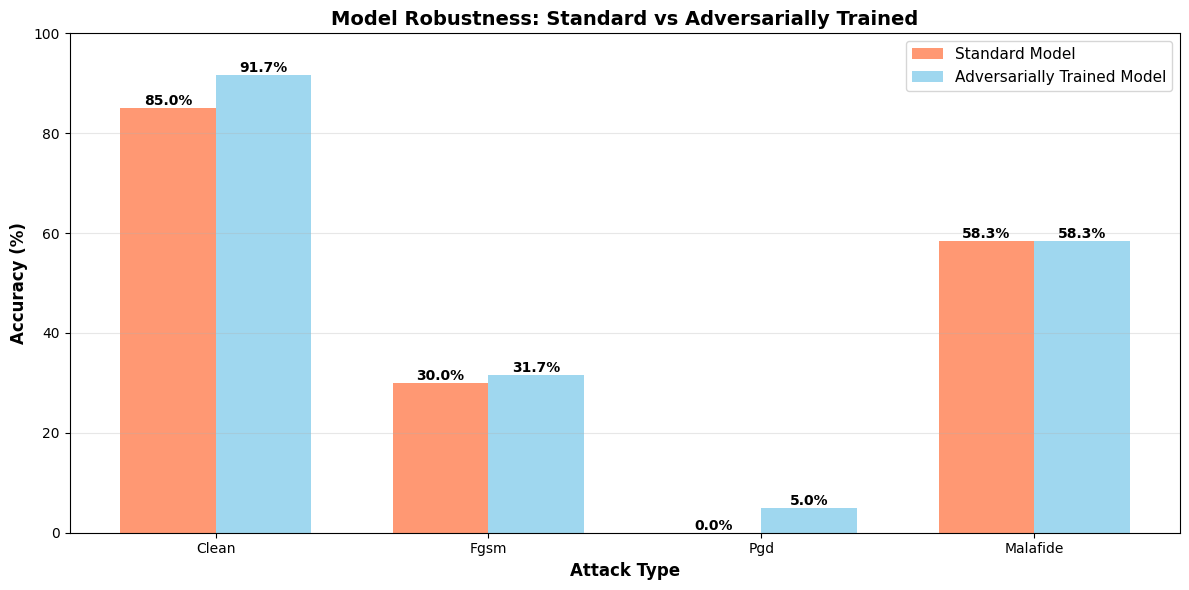


SUMMARY

CLEAN:
  Standard Model:        85.00%
  Adversarially Trained: 91.67%
  Improvement:           +6.67 percentage points

FGSM:
  Standard Model:        30.00%
  Adversarially Trained: 31.67%
  Improvement:           +1.67 percentage points

PGD:
  Standard Model:        0.00%
  Adversarially Trained: 5.00%
  Improvement:           +5.00 percentage points

MALAFIDE:
  Standard Model:        58.33%
  Adversarially Trained: 58.33%
  Improvement:           +0.00 percentage points

✅ ROBUSTNESS COMPARISON COMPLETE


In [15]:
import os
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model

# ============================================================================
# ROBUSTNESS COMPARISON PLOT - CORAL & SKYBLUE
# ============================================================================

WORK_DIR = "./working"

print("=" * 70)
print("GENERATING ROBUSTNESS COMPARISON PLOT")
print("=" * 70)

# Load models
print("\n1️⃣ Loading models...")
try:
    model_standard = load_model(os.path.join(WORK_DIR, "deepfake_detection_best.keras"))
    print("   ✓ Standard model loaded")
except Exception as e:
    print(f"   ❌ Error loading standard model: {e}")
    model_standard = None

try:
    model_adv_trained = load_model(os.path.join(WORK_DIR, "deepfake_adv_trained_final.keras"))
    print("   ✓ Adversarially trained model loaded")
except Exception as e:
    print(f"   ❌ Error loading adversarially trained model: {e}")
    model_adv_trained = None

# Load test data
print("\n2️⃣ Loading test data...")
try:
    X_test = np.load(os.path.join(WORK_DIR, "X_test.npy"))
    y_test = np.load(os.path.join(WORK_DIR, "y_test.npy"))
    print(f"   ✓ Test data loaded: X_test {X_test.shape}, y_test {y_test.shape}")
except Exception as e:
    print(f"   ❌ Error loading test data: {e}")
    X_test = None
    y_test = None

# Load adversarial examples
print("\n3️⃣ Loading adversarial examples...")
adversarial_examples = {}

try:
    X_adv_fgsm = np.load(os.path.join(WORK_DIR, 'X_test_fgsm_adversarial.npy'))
    adversarial_examples['fgsm'] = X_adv_fgsm
    print("   ✓ FGSM examples loaded")
except FileNotFoundError:
    print("   ✗ FGSM examples MISSING")

try:
    X_adv_pgd = np.load(os.path.join(WORK_DIR, 'X_test_pgd_adversarial.npy'))
    adversarial_examples['pgd'] = X_adv_pgd
    print("   ✓ PGD examples loaded")
except FileNotFoundError:
    print("   ✗ PGD examples MISSING")

try:
    X_adv_malafide = np.load(os.path.join(WORK_DIR, 'X_test_malafide_adversarial.npy'))
    adversarial_examples['malafide'] = X_adv_malafide
    print("   ✓ 2D-Malafide examples loaded")
except FileNotFoundError:
    print("   ✗ 2D-Malafide examples MISSING")

# Evaluate models
if model_standard and model_adv_trained and X_test is not None and len(adversarial_examples) > 0:
    print("\n4️⃣ Evaluating models...")
    print("-" * 70)
    
    results = {}
    
    # Clean data
    print("📊 Clean data (no attack)...")
    std_clean_loss, std_clean_acc = model_standard.evaluate(X_test, y_test, verbose=0)
    adv_clean_loss, adv_clean_acc = model_adv_trained.evaluate(X_test, y_test, verbose=0)
    results['clean'] = {'std': std_clean_acc, 'adv': adv_clean_acc}
    print(f"   Standard: {std_clean_acc*100:.2f}% | Adversarial: {adv_clean_acc*100:.2f}%")
    
    # Adversarial examples
    for attack_name, X_adv in adversarial_examples.items():
        print(f"📊 {attack_name.upper()} attack...")
        std_adv_loss, std_adv_acc = model_standard.evaluate(X_adv, y_test, verbose=0)
        adv_adv_loss, adv_adv_acc = model_adv_trained.evaluate(X_adv, y_test, verbose=0)
        results[attack_name] = {'std': std_adv_acc, 'adv': adv_adv_acc}
        print(f"   Standard: {std_adv_acc*100:.2f}% | Adversarial: {adv_adv_acc*100:.2f}%")
    
    # Create plot with CORAL and SKYBLUE colors
    print("\n5️⃣ Creating comparison plot...")
    print("-" * 70)
    
    attack_types = list(results.keys())
    std_accuracies = [results[attack]['std'] * 100 for attack in attack_types]
    adv_accuracies = [results[attack]['adv'] * 100 for attack in attack_types]
    
    x = np.arange(len(attack_types))
    width = 0.35
    
    fig, ax = plt.subplots(figsize=(12, 6))
    
    # Use CORAL and SKYBLUE colors
    bars1 = ax.bar(x - width/2, std_accuracies, width, 
                   label='Standard Model', alpha=0.8, color='coral')
    bars2 = ax.bar(x + width/2, adv_accuracies, width, 
                   label='Adversarially Trained Model', alpha=0.8, color='skyblue')
    
    ax.set_xlabel('Attack Type', fontsize=12, fontweight='bold')
    ax.set_ylabel('Accuracy (%)', fontsize=12, fontweight='bold')
    ax.set_title('Model Robustness: Standard vs Adversarially Trained', 
                fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels([t.capitalize() for t in attack_types])
    ax.legend(fontsize=11)
    ax.set_ylim([0, 100])
    ax.grid(axis='y', alpha=0.3)
    
    # Add value labels on bars
    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height,
                   f'{height:.1f}%',
                   ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    plt.tight_layout()
    
    # Save plot
    plot_path = os.path.join(WORK_DIR, 'robustness_comparison_coral_skyblue.png')
    plt.savefig(plot_path, dpi=300, bbox_inches='tight')
    print(f"✓ Plot saved to {plot_path}")
    plt.show()
    
    # Print summary
    print("\n" + "=" * 70)
    print("SUMMARY")
    print("=" * 70)
    for attack_name in results.keys():
        std_acc = results[attack_name]['std'] * 100
        adv_acc = results[attack_name]['adv'] * 100
        improvement = adv_acc - std_acc
        
        print(f"\n{attack_name.upper()}:")
        print(f"  Standard Model:        {std_acc:.2f}%")
        print(f"  Adversarially Trained: {adv_acc:.2f}%")
        print(f"  Improvement:           {improvement:+.2f} percentage points")
    
    print("\n" + "=" * 70)
    print("✅ ROBUSTNESS COMPARISON COMPLETE")
    print("=" * 70)
    
else:
    print("\n❌ Missing required models or data. Cannot create plot.")
    print("   Make sure you have:")
    print("   - deepfake_detection_best.keras")
    print("   - deepfake_adv_trained_final.keras")
    print("   - X_test.npy and y_test.npy")
    print("   - Adversarial example files (FGSM, PGD, Malafide)")
